# Data Cleaning with Pandas — Line by Line
## Every Line of Code Explained | Prodigy Training Hub

---

> **How to use this notebook:**
> Every code cell is preceded by a markdown cell that explains **each line individually**.
> Read the explanation first, then run the cell.
> All cells use the dataset: **`nigeria_cleaning_dataset.csv`** and **`nigeria_cleaning_dataset.xlsx`**

---

### Topics Covered
| Section | Topic |
|---|---|
| 0 | Setup and Loading |
| 1 | Data Cleaning Introduction |
| 2 | Cleaning Empty Cells |
| 3 | Cleaning Wrong Format |
| 4 | Cleaning Wrong Data |
| 5 | Removing Duplicates |
| 6 | Complete Pipeline |
| 7 | Post-Cleaning Analysis |
| 8 | Applying Cleaning to Excel Sheets |

---

---
# SECTION 0: Setup

---

## Cell 0.1 — Import Libraries

This is always the very first cell in any data analysis notebook. We bring in all the tools we will use.

---

**`import pandas as pd`**
Loads the Pandas library. `pd` is the universally agreed shortcut name. Every data analyst in the world uses `pd`. It means instead of writing `pandas.read_csv()` every time, you just write `pd.read_csv()`.

---

**`import numpy as np`**
Loads NumPy — the numerical computing library. Pandas is built on top of NumPy. We use `np` whenever we need `np.nan` (a missing value marker), `np.where()` (conditional logic), or mathematical array operations.

---

**`import matplotlib.pyplot as plt`**
Loads Matplotlib for creating charts. `plt` is the standard shortcut. Every chart in this notebook is drawn using `plt`.

---

**`import re`**
Loads Python's built-in `re` (regular expressions) module. We use this for email and phone number validation — pattern matching.

---

**`import warnings`**
**`warnings.filterwarnings('ignore')`**
Pandas sometimes prints minor warning messages that are not errors — they just clutter the output. These two lines suppress those warnings silently.

---

**`%matplotlib inline`**
This is a **Jupyter magic command** (commands that start with `%` are special instructions to Jupyter itself, not Python). This tells Jupyter to display every chart directly inside the notebook, right below the cell that created it.

---

**`pd.set_option('display.max_columns', 22)`**
Tells Pandas to show up to 22 columns in the notebook output before collapsing the rest with `...`. Our dataset has 20 columns, so this ensures all columns are visible.

**`pd.set_option('display.max_rows', 40)`**
Show up to 40 rows before truncating. Useful when printing large DataFrames.

**`pd.set_option('display.width', 130)`**
Use 130 characters of horizontal width before wrapping. Wider = fewer line breaks in the output.

**`pd.set_option('display.float_format', '{:,.2f}'.format)`**
Format all decimal numbers with commas and 2 decimal places throughout the notebook.
For example: `318717.7234` displays as `318,717.72`. Much easier to read.

---

**`print("Libraries loaded. Pandas:", pd.__version__)`**
`pd.__version__` is a special attribute that holds the version number of the installed Pandas. Printing this confirms everything loaded correctly.

In [1]:
import pandas as pd             # data analysis library — aliased as pd
import numpy as np              # numerical computing — aliased as np
import matplotlib.pyplot as plt  # plotting library — aliased as plt
import re                        # regular expressions — for phone/email validation
import warnings                  # built-in Python warning control
warnings.filterwarnings('ignore') # suppress minor Pandas warning messages
%matplotlib inline

pd.set_option('display.max_columns', 22)              # show up to 22 columns
pd.set_option('display.max_rows', 40)                 # show up to 40 rows
pd.set_option('display.width', 130)                   # 130-character display width
pd.set_option('display.float_format', '{:,.2f}'.format) # format floats: 318,717.72

print("Libraries loaded. Pandas:", pd.__version__)

Libraries loaded. Pandas: 2.3.1


---
## Cell 0.2 — Load the Raw Dataset

---

**`df_raw = pd.read_csv('nigeria_cleaning_dataset.csv')`**
`pd.read_csv()` reads a CSV file from disk and returns it as a Pandas DataFrame.
`'nigeria_cleaning_dataset.csv'` is the filename — it must be in the **same folder** as this notebook.
We store the result in `df_raw`. The `_raw` suffix is a convention meaning "the original, untouched data". We never modify `df_raw` — it is our safety backup.

---

**`print(f"Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")`**
`df_raw.shape` is a **tuple** — a pair of numbers `(rows, columns)`.
`df_raw.shape[0]` picks the first element: the number of rows.
`df_raw.shape[1]` picks the second element: the number of columns.
The `f"..."` is an **f-string** — it lets you embed Python variables directly inside a string using `{}`.
So if shape is (630, 20), this prints: `Raw dataset: 630 rows × 20 columns`.

---

**`print()`**
Prints a blank line — just for visual spacing in the output. Makes it easier to read.

---

**`print("=== First 5 rows ===")`**
Prints a section header label in the output. The `===` signs are just decorative separators.

---

**`print(df_raw.head())`**
`df_raw.head()` returns the first 5 rows of the DataFrame (default is 5; you can pass a number like `head(10)`).
`print()` displays it in the notebook output.
This is the **most important first command** after loading data — it lets you visually confirm what the data looks like: column names, data values, types at a glance.

In [2]:
# Load the CSV — no parse_dates yet; we want to see the messy raw data first
df_raw = pd.read_csv('nigeria_cleaning_dataset.csv')
# pd.read_csv() reads the file and returns a DataFrame stored in df_raw

print(f"Raw dataset: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
# df_raw.shape is a tuple (rows, cols); [0] = rows, [1] = columns
print()
print("=== First 5 rows ===")
print(df_raw.head())  # head() shows the first 5 rows by default

Raw dataset: 630 rows x 20 columns

=== First 5 rows ===
     order_id  order_date customer_name         customer_email   customer_phone   state platform   category  \
0  ORD-100000  2023-01-01   Customer_15  customer0@example.com              NaN  Rivers    Konga     Sports   
1  ORD-100001  2023-01-02   Customer_28  customer1@example.com 8,076,317,456.00     Imo     Jiji      Books   
2  ORD-100002  03/01/2023    Customer_4  customer2@example.com 8,073,801,590.00  Kaduna     Jiji  Furniture   
3  ORD-100003  2023-01-04   Customer_36  customer3@example.com 8,094,850,555.00     Imo    Jumia     Sports   
4  ORD-100004  2023-01-05   Customer_65  customer4@example.com 8,041,394,931.00   Abuja     Jiji  Groceries   

              product_name  unit_price  quantity  discount_pct  total_amount   payment_method  customer_age customer_gender  \
0        Yoga Mat Non-Slip   91,292.33         4            15    310,393.92              POS         64.00          Female   
1         ACCA F3 Text

---
## Cell 0.3 — Full Data Audit

Run this on EVERY new dataset before touching anything. It answers five questions in one cell.

---

**`print("=" * 60)`**
`"=" * 60` uses Python's string repetition — it creates a string of 60 `=` signs.
This is a visual separator line to make the output easier to read.

---

**`print(f"Rows    : {df_raw.shape[0]}")`**
Prints the row count. `df_raw.shape[0]` is the first element of the shape tuple — number of rows.

**`print(f"Columns : {df_raw.shape[1]}")`**
Prints the column count. `df_raw.shape[1]` is the second element — number of columns.

---

**`print(df_raw.dtypes)`**
`dtypes` is an attribute (not a function — no parentheses). It shows the **data type** of every column.
Key types: `object` = text/mixed, `int64` = whole numbers, `float64` = decimal numbers, `datetime64` = dates.
Wrong data types (e.g., dates stored as `object`) are a major cleaning issue.

---

**`miss = df_raw.isnull().sum()`**
`df_raw.isnull()` returns a DataFrame of `True`/`False` — `True` where a cell is NaN (missing).
`.sum()` counts the `True` values per column. In Python, `True = 1` and `False = 0`, so summing counts the missing values.
`miss` is now a Series where each value is the count of missing cells in that column.

**`miss_pct = (miss / len(df_raw) * 100).round(1)`**
`len(df_raw)` = total number of rows.
`miss / len(df_raw)` = fraction missing (0.0 to 1.0).
`* 100` = converts to percentage.
`.round(1)` = rounds to 1 decimal place.

**`audit = pd.DataFrame({'Count': miss, 'Pct %': miss_pct})`**
`pd.DataFrame({...})` creates a new DataFrame from a dictionary.
`'Count': miss` and `'Pct %': miss_pct` become the two columns.
This builds a clean two-column summary table.

**`print(audit[audit['Count'] > 0])`**
`audit['Count'] > 0` is a boolean condition — `True` for columns that HAVE missing values.
`audit[...]` filters the DataFrame to only show those rows.
Result: a table showing ONLY the columns with missing data. Clean columns are hidden.

---

**`print(f"=== Duplicate Rows : {df_raw.duplicated().sum()} ===")`**
`df_raw.duplicated()` returns a boolean Series — `True` for duplicate rows (second/later occurrences).
`.sum()` counts the `True` values = counts the duplicate rows.

---

**`print(df_raw.describe())`**
`describe()` computes statistical summary for numeric columns: count, mean, std, min, 25%, 50%, 75%, max.
Critical for spotting wrong data: look at `min` and `max`. If age has `min = -5` or `max = 999` — that is wrong data.

In [3]:
print("=" * 60)         # "=" * 60 creates a string of 60 equal signs — a visual separator
print("FULL DATA AUDIT")
print("=" * 60)
print()

# 1. Shape — how big is the dataset?
print(f"Rows    : {df_raw.shape[0]}")  # shape[0] = number of rows
print(f"Columns : {df_raw.shape[1]}")  # shape[1] = number of columns
print()

# 2. Data types — is each column the right type?
print("=== Data Types ===")
print(df_raw.dtypes)   # dtypes is an attribute — shows type of every column
print()

# 3. Missing values — how many NaN per column?
print("=== Missing Values ===")
miss     = df_raw.isnull().sum()                    # isnull() gives True/False; sum() counts Trues
miss_pct = (miss / len(df_raw) * 100).round(1)     # convert count to percentage
audit    = pd.DataFrame({'Count': miss, 'Pct %': miss_pct})  # build a 2-column summary table
print(audit[audit['Count'] > 0])                   # show ONLY columns that have missing values
print()

# 4. Duplicates
print(f"=== Duplicate Rows : {df_raw.duplicated().sum()} ===")  # duplicated().sum() = count duplicate rows
print()

# 5. Statistical summary — spot impossible min/max values (wrong data)
print("=== Numeric Summary (spot impossible min/max) ===")
print(df_raw.describe())  # count, mean, std, min, 25%, 50%, 75%, max for every numeric column

FULL DATA AUDIT

Rows    : 630
Columns : 20

=== Data Types ===
order_id             object
order_date           object
customer_name        object
customer_email       object
customer_phone      float64
state                object
platform             object
category             object
product_name         object
unit_price          float64
quantity              int64
discount_pct          int64
total_amount        float64
payment_method       object
customer_age        float64
customer_gender      object
customer_segment     object
rating              float64
delivery_days       float64
returned               bool
dtype: object

=== Missing Values ===
                Count  Pct %
order_date         25   4.00
customer_name      31   4.90
customer_email     22   3.50
customer_phone     15   2.40
state              10   1.60
total_amount       13   2.10
customer_age       41   6.50
rating             36   5.70
delivery_days      11   1.70

=== Duplicate Rows : 30 ===

=== Numeric Summar

---
## Cell 0.4 — Visualise Missing Values as a Bar Chart

---

**`miss_data = df_raw.isnull().sum()`**
Same as before — creates a Series where each value is the missing count for that column.

**`miss_data = miss_data[miss_data > 0].sort_values(ascending=False)`**
`miss_data > 0` filters to only columns that have missing values.
`.sort_values(ascending=False)` sorts from most missing to least.
`ascending=False` means descending order — largest count first.

---

**`fig, ax = plt.subplots(figsize=(12, 5))`**
`plt.subplots()` creates a figure and one set of axes (the actual plot area).
`fig` = the overall canvas. `ax` = the drawing area where the chart lives.
`figsize=(12, 5)` = width 12 inches, height 5 inches.
We always separate `fig` and `ax` because it gives us precise control over the chart.

---

**`colors_bar = ['#dc2626' if v > 30 else '#f97316' if v > 15 else '#facc15' for v in miss_data.values]`**
This is a **list comprehension** — Python's compact way to build a list using a loop.
`for v in miss_data.values` loops through each missing count value.
`'#dc2626' if v > 30` — assign dark red if more than 30 missing.
`else '#f97316' if v > 15` — assign orange if more than 15.
`else '#facc15'` — assign yellow for lower counts.
Result: a list of hex colour codes, one per bar, based on severity.

---

**`miss_data.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white', alpha=0.9)`**
`.plot()` is Pandas' built-in charting method.
`kind='bar'` = vertical bar chart.
`ax=ax` = draw on our specific axes object.
`color=colors_bar` = use our list of colours (one per bar).
`edgecolor='white'` = white border around each bar for a clean look.
`alpha=0.9` = 90% opacity (slight transparency).

---

**`ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.set_ylabel(...)`**
These set the chart title and axis labels. `fontsize=` controls text size. `pad=12` adds space between the title and the chart.

**`ax.tick_params(axis='x', rotation=35)`**
Rotates the x-axis labels by 35 degrees so they don't overlap each other.

---

**`for bar in ax.patches:`**
`ax.patches` is a list of all the bar objects in the chart.
This loop lets us add a label on top of each bar.

**`h = bar.get_height()`**
Gets the height (value) of the current bar — this is the missing count.

**`pct = h / len(df_raw) * 100`**
Calculates what percentage of rows this missing count represents.

**`ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)} ({pct:.1f}%)', ha='center', va='bottom', fontsize=8, fontweight='bold')`**
`ax.text(x, y, text, ...)` places a text label at position (x, y) on the chart.
`bar.get_x() + bar.get_width()/2` = horizontal centre of the bar.
`h + 0.5` = just above the top of the bar.
`f'{int(h)} ({pct:.1f}%)'` = the label showing count and percentage.
`ha='center'` = horizontal alignment centred.
`va='bottom'` = vertical alignment at the bottom of the text (so text sits above the bar).

---

**`plt.tight_layout()`**
Automatically adjusts spacing so nothing overlaps or gets clipped.

**`plt.savefig('missing_values_audit.png', dpi=150, bbox_inches='tight')`**
Saves the chart as a PNG image file. `dpi=150` = good resolution. `bbox_inches='tight'` = no whitespace cropping.

**`plt.show()`**
Displays the chart in the notebook.

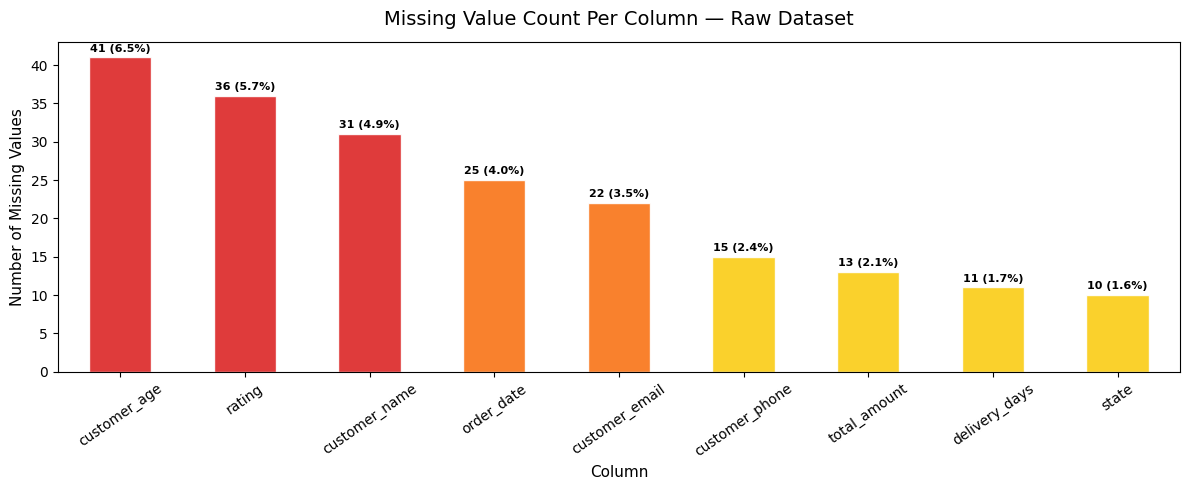

Chart saved.


In [4]:
miss_data = df_raw.isnull().sum()                              # count missing per column
miss_data = miss_data[miss_data > 0].sort_values(ascending=False) # keep only columns with missing, sort largest first

fig, ax = plt.subplots(figsize=(12, 5))
# fig = the overall canvas; ax = the drawing area; figsize = (width, height) in inches

# Colour each bar by severity: red (>30), orange (>15), yellow (<=15)
colors_bar = ['#dc2626' if v > 30 else '#f97316' if v > 15 else '#facc15'
              for v in miss_data.values]
# List comprehension: for each value v, pick a colour based on how severe the missing count is

miss_data.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white', alpha=0.9)
# kind='bar' = vertical bar chart; color uses our severity colours; alpha=0.9 = slight transparency

ax.set_title('Missing Value Count Per Column — Raw Dataset', fontsize=14, pad=12)
ax.set_xlabel('Column', fontsize=11)          # x-axis label
ax.set_ylabel('Number of Missing Values', fontsize=11)  # y-axis label
ax.tick_params(axis='x', rotation=35)         # tilt x labels 35° so they don't overlap

for bar in ax.patches:           # ax.patches is a list of all bar rectangle objects
    h = bar.get_height()         # get the height (value) of this bar
    pct = h / len(df_raw) * 100  # convert to percentage of total rows
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position: horizontal centre of the bar
        h + 0.5,                             # y position: just above the top of the bar
        f'{int(h)} ({pct:.1f}%)',            # label text: count and percentage
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

plt.tight_layout()  # auto-adjust spacing to prevent overlapping elements
plt.savefig('missing_values_audit.png', dpi=150, bbox_inches='tight')  # save as PNG
plt.show()          # display in the notebook
print("Chart saved.")

---
# SECTION 1: Introduction to Data Cleaning

---

## Cell 1.1 — The Cleaning Report Function

---

**`def cleaning_report(dataframe, name="Dataset"):`**
`def` starts the definition of a new function called `cleaning_report`.
It takes two **parameters**: `dataframe` (the DataFrame to audit) and `name` (a label for the report, defaults to `"Dataset"` if not provided).
A function is a reusable block of code — define it once, call it anywhere.

---

**`print("=" * 65)`**
Prints a line of 65 equals signs — a visual header border.

**`print(f"CLEANING REPORT — {name}")`**
`{name}` inside the f-string inserts the `name` parameter value.

---

**`print(f"  Shape        : {dataframe.shape[0]} rows × {dataframe.shape[1]} columns")`**
`dataframe.shape[0]` = rows. `dataframe.shape[1]` = columns. Two spaces at the start indent the output for readability.

**`print(f"  Duplicates   : {dataframe.duplicated().sum()} duplicate rows")`**
`dataframe.duplicated()` = boolean Series (True for duplicates). `.sum()` = count of True values.

**`print(f"  Total cells  : {dataframe.size}")`**
`dataframe.size` = total number of cells = rows × columns.

**`total_null = dataframe.isnull().sum().sum()`**
First `.sum()` = sum per column (a Series of counts).
Second `.sum()` = sum of that Series = total missing cells across the entire DataFrame.

**`print(f"  Missing cells: {total_null} ({total_null/dataframe.size*100:.1f}% of all cells)")`**
`total_null/dataframe.size*100` = percentage of all cells that are missing.
`:.1f` formats the float to 1 decimal place.

---

**`miss = dataframe.isnull().sum()`**
Per-column missing count.

**`miss = miss[miss > 0]`**
Filter: keep only columns that actually have missing values. Columns with zero missing are dropped from the display.

**`if len(miss):`**
`len(miss)` = number of columns with missing values. If it is greater than 0 (truthy), the block runs.
If there are no missing values at all, this block is skipped.

**`for col, cnt in miss.items():`**
`.items()` on a Series returns `(index_label, value)` pairs.
Here: `col` = column name, `cnt` = missing count for that column.

**`print(f"    {col:<22} {cnt:>4} missing  ({cnt/len(dataframe)*100:.1f}%)")`**
`{col:<22}` = left-align `col` in a field of 22 characters (padding with spaces if shorter).
`{cnt:>4}` = right-align `cnt` in a field of 4 characters.
This creates a neat aligned table in the output.

---

**`cleaning_report(df_raw, "nigeria_cleaning_dataset.csv")`**
This **calls** the function we just defined, passing `df_raw` as the DataFrame and the filename as the name. The report prints immediately.

In [5]:
# Define a reusable function that runs a full dirt audit on any DataFrame
def cleaning_report(dataframe, name="Dataset"):   # def creates a function; name defaults to "Dataset"
    print("=" * 65)
    print(f"CLEANING REPORT — {name}")             # f-string: inserts the name argument
    print("=" * 65)
    print(f"  Shape        : {dataframe.shape[0]} rows x {dataframe.shape[1]} columns")
    # shape[0] = rows, shape[1] = columns

    print(f"  Duplicates   : {dataframe.duplicated().sum()} duplicate rows")
    # duplicated() = True/False per row; .sum() counts Trues

    print(f"  Total cells  : {dataframe.size}")
    # size = rows x columns = total number of cells

    total_null = dataframe.isnull().sum().sum()
    # first .sum() = per-column missing counts (a Series)
    # second .sum() = adds all those counts together = total missing cells
    print(f"  Missing cells: {total_null} ({total_null/dataframe.size*100:.1f}% of all cells)")

    print()
    miss = dataframe.isnull().sum()       # missing count per column
    miss = miss[miss > 0]                 # filter: keep only columns that HAVE missing values
    if len(miss):                         # if any columns have missing values...
        print("  Columns with missing values:")
        for col, cnt in miss.items():     # .items() yields (column_name, missing_count) pairs
            print(f"    {col:<22} {cnt:>4} missing  ({cnt/len(dataframe)*100:.1f}%)")
            # :<22 left-aligns column name in 22 chars; :>4 right-aligns count in 4 chars
    print("=" * 65)

cleaning_report(df_raw, "nigeria_cleaning_dataset.csv")  # CALL the function with our raw data

CLEANING REPORT — nigeria_cleaning_dataset.csv
  Shape        : 630 rows x 20 columns
  Duplicates   : 30 duplicate rows
  Total cells  : 12600
  Missing cells: 204 (1.6% of all cells)

  Columns with missing values:
    order_date               25 missing  (4.0%)
    customer_name            31 missing  (4.9%)
    customer_email           22 missing  (3.5%)
    customer_phone           15 missing  (2.4%)
    state                    10 missing  (1.6%)
    total_amount             13 missing  (2.1%)
    customer_age             41 missing  (6.5%)
    rating                   36 missing  (5.7%)
    delivery_days            11 missing  (1.7%)


---
# SECTION 2: Cleaning Empty Cells

---

## Cell 2.1 — Detecting Empty Cells

---

**`df = df_raw.copy()`**
`.copy()` creates a completely independent copy of `df_raw`.
From this point forward, ALL cleaning work happens on `df` — never on `df_raw`.
This is a professional safety habit: if something goes wrong, `df_raw` is always there as the untouched original.

---

**`print(df[['customer_name','customer_age','rating','total_amount']].isnull().head(8))`**
`df[['customer_name','customer_age','rating','total_amount']]` selects just those 4 columns.
`.isnull()` applies to the selected columns and returns `True` where a cell is NaN, `False` where it has data.
`.head(8)` shows the first 8 rows.
Purpose: visually demonstrate what isnull() output looks like.

---

**`print(df.isnull().sum())`**
`df.isnull()` returns a full True/False DataFrame (every column).
`.sum()` counts the True values per column = missing count per column.
Prints a Series showing how many NaN values exist in each column.

---

**`total_null = df.isnull().sum().sum()`**
First `.sum()` → a Series of per-column counts.
Second `.sum()` → adds ALL those counts = one single number: total missing cells in the entire DataFrame.

**`print(f"Total missing cells: {total_null} out of {df.size} ({total_null/df.size*100:.1f}%)")`**
`df.size` = total number of cells (rows × columns).
`total_null/df.size*100` = what percentage of all cells are missing.
`:.1f` = format to 1 decimal place.

In [6]:
df = df_raw.copy()  # create an independent copy — all cleaning work happens on df, not df_raw

# isnull() returns True where a cell is NaN (missing), False where it has a value
print("=== isnull() output — first 8 rows, 4 columns ===")
print(df[['customer_name','customer_age','rating','total_amount']].isnull().head(8))
# Select 4 columns, apply isnull(), show first 8 rows — True = missing, False = present
print()

# Count missing values per column: isnull() gives True/False; sum() counts Trues
print("=== Missing value count per column ===")
print(df.isnull().sum())
print()

# Total missing cells in the entire DataFrame
total_null = df.isnull().sum().sum()
# first .sum() = per-column counts (Series); second .sum() = adds all counts = single total
print(f"Total missing cells: {total_null} out of {df.size} ({total_null/df.size*100:.1f}%)")
# df.size = total cells = rows x columns

=== isnull() output — first 8 rows, 4 columns ===
   customer_name  customer_age  rating  total_amount
0          False         False    True         False
1          False          True    True         False
2          False         False   False         False
3          False         False   False         False
4          False         False   False         False
5          False         False   False         False
6           True         False   False         False
7          False         False   False         False

=== Missing value count per column ===
order_id             0
order_date          25
customer_name       31
customer_email      22
customer_phone      15
state               10
platform             0
category             0
product_name         0
unit_price           0
quantity             0
discount_pct         0
total_amount        13
payment_method       0
customer_age        41
customer_gender      0
customer_segment     0
rating              36
delivery_days      

---
## Cell 2.2 — Viewing Rows with Missing Values

---

**`rows_missing_age = df[df['customer_age'].isnull()]`**
`df['customer_age'].isnull()` = a boolean Series — True where customer_age is NaN.
`df[...]` = filter: keep only rows where the condition is True.
`rows_missing_age` now contains ONLY the rows where customer_age is missing.

**`print(f"Rows with missing customer_age: {len(rows_missing_age)}")`**
`len()` counts how many rows are in the filtered result.

**`print(rows_missing_age[['order_id','customer_name','customer_age','state']].head(8))`**
Shows only 4 selected columns from those missing-age rows, first 8 of them.
Useful for understanding the pattern — are missing ages concentrated in a state or customer group?

---

**`rows_any_null = df[df.isnull().any(axis=1)]`**
`df.isnull()` = True/False DataFrame for every cell.
`.any(axis=1)` = checks across each row — returns True if AT LEAST ONE cell in that row is NaN.
`axis=1` means "across columns" (row-wise check). `axis=0` would mean "down rows" (column-wise).
`df[...]` filters to only those rows.

---

**`rows_all_null = df[df.isnull().all(axis=1)]`**
`.all(axis=1)` = returns True only if EVERY cell in a row is NaN — a completely empty row.
These are very rare but important to detect before filling — filling a fully empty row produces garbage.

In [7]:
# Filter to show ONLY rows where customer_age is NaN
rows_missing_age = df[df['customer_age'].isnull()]
# df['customer_age'].isnull() = boolean Series (True where NaN)
# df[...] filters: keep only rows where the condition is True
print(f"Rows with missing customer_age: {len(rows_missing_age)}")
print(rows_missing_age[['order_id','customer_name','customer_age','state']].head(8))
# Show only 4 columns for readability; head(8) = first 8 rows
print()

# Rows missing AT LEAST ONE value — .any(axis=1) checks across columns (row-wise)
rows_any_null = df[df.isnull().any(axis=1)]
# axis=1 = check across columns for each row; True if any cell in the row is NaN
print(f"Rows with AT LEAST ONE missing value: {len(rows_any_null)}")

# Rows where ALL values are missing — .all(axis=1) = True only if every cell in the row is NaN
rows_all_null = df[df.isnull().all(axis=1)]
print(f"Rows where ALL values are missing  : {len(rows_all_null)}")

Rows with missing customer_age: 41
       order_id customer_name  customer_age    state
1    ORD-100001   Customer_28           NaN      Imo
39   ORD-100039   Customer_90           NaN    Abuja
57   ORD-100057   Customer_30           NaN      Imo
70   ORD-100070   Customer_85           NaN  Anambra
96   ORD-100096   Customer_24           NaN    Abuja
102  ORD-100102    Customer_4           NaN   Kaduna
109  ORD-100109   Customer_31           NaN      Imo
128  ORD-100128   Customer_48           NaN      Imo

Rows with AT LEAST ONE missing value: 176
Rows where ALL values are missing  : 0


---
## Cell 2.3 — Strategy 1: `dropna()` — Remove Rows with Missing Values

---

**`df_dropped_any = df.dropna()`**
`dropna()` removes every row that has ANY missing value in ANY column.
This is the most aggressive option — it can remove a large portion of your data.
We store the result in `df_dropped_any` and do NOT modify `df` — we are comparing strategies.

**`print(f"Original rows        : {len(df)}")`**
`len(df)` = number of rows in `df`.

**`print(f"After dropna()       : {len(df_dropped_any)}")`**
How many rows survived — all rows that had at least one NaN were removed.

**`print(f"Rows removed         : {len(df) - len(df_dropped_any)}")`**
The difference = how many rows were lost. This is often a large number, which is why `dropna()` alone is rarely the right solution for real datasets.

---

**`df_dropped_subset = df.dropna(subset=['order_id', 'customer_name'])`**
`subset=['order_id', 'customer_name']` tells dropna: "only remove a row if it is missing a value in THESE specific columns."
A row with a missing `rating` but a valid `order_id` and `customer_name` would be KEPT.
This is the most practical version of dropna for real work — you define what columns are critical.

---

**`df_dropped_all = df.dropna(how='all')`**
`how='all'` means: only remove a row if EVERY single column is NaN (a completely empty row).
This is the mildest option — only removes rows that are completely useless.

---

**`df_dropped_thresh = df.dropna(thresh=15)`**
`thresh=15` means: keep a row only if it has at least 15 non-null values.
Our dataset has 20 columns, so a row with fewer than 15 values present (more than 5 missing) is removed.
`thresh` gives you a flexible middle ground between `any` and `all`.

In [8]:
# dropna() with NO arguments — remove every row that has ANY missing value
df_dropped_any = df.dropna()
# This is the most aggressive option — stores result in new variable, does NOT modify df
print(f"Original rows        : {len(df)}")           # len() counts rows
print(f"After dropna()       : {len(df_dropped_any)}")
print(f"Rows removed         : {len(df) - len(df_dropped_any)}")
print()

# dropna(subset=[...]) — only remove rows where SPECIFIC columns are NaN
df_dropped_subset = df.dropna(subset=['order_id', 'customer_name'])
# A row missing only 'rating' but having valid order_id and customer_name is KEPT
print(f"After dropna(subset=['order_id','customer_name']): {len(df_dropped_subset)} rows")
print()

# dropna(how='all') — only remove rows where EVERY value is NaN (completely empty rows)
df_dropped_all = df.dropna(how='all')
print(f"After dropna(how='all'): {len(df_dropped_all)} rows (only completely empty rows removed)")
print()

# dropna(thresh=n) — keep rows that have at least n non-null values
df_dropped_thresh = df.dropna(thresh=15)
# Our dataset has 20 columns; thresh=15 means: keep row only if at least 15 values are present
print(f"After dropna(thresh=15): {len(df_dropped_thresh)} rows")

Original rows        : 630
After dropna()       : 454
Rows removed         : 176

After dropna(subset=['order_id','customer_name']): 599 rows

After dropna(how='all'): 630 rows (only completely empty rows removed)

After dropna(thresh=15): 630 rows


---
## Cell 2.4 — Strategy 2: Fill with Mean

---

**`df_filled = df.copy()`**
Create another working copy. We are testing different fill strategies and want each one independent.

---

**`valid_ages = df_filled['customer_age'].apply(pd.to_numeric, errors='coerce')`**
`df_filled['customer_age']` = the customer_age column as a Series.
`.apply(pd.to_numeric, errors='coerce')` = applies the `pd.to_numeric` function to every value.
`errors='coerce'` means: if a value cannot be converted to a number (e.g., a stray string), replace it with NaN instead of crashing.
This ensures we have a proper numeric Series before computing the mean.

**`valid_ages = valid_ages[valid_ages <= 100]`**
Filter out impossible ages (999) BEFORE computing the mean.
If we included age 999 in the mean calculation, the mean would be pulled far upward — giving us a wrong fill value. Filtering to `<= 100` ensures we compute the mean only from realistic ages.

**`age_mean = valid_ages.mean()`**
`.mean()` computes the arithmetic average, automatically ignoring any remaining NaN values.

---

**`df_filled['customer_age'] = pd.to_numeric(df_filled['customer_age'], errors='coerce')`**
Convert the full column to numeric. Any truly non-numeric values become NaN. This is a clean-up step before filling.

**`df_filled['customer_age'].fillna(age_mean, inplace=True)`**
`fillna(value)` replaces every NaN in the column with `value`.
`inplace=True` modifies the column directly inside `df_filled` without creating a new object.
Without `inplace=True`, `fillna()` returns a new Series but does NOT change `df_filled` — a common beginner mistake.

In [9]:
df_filled = df.copy()  # independent copy — test fill strategies here without affecting df

# Fill customer_age with MEAN
# But first: exclude outlier ages (999) from the mean calculation — they would inflate it
valid_ages = df_filled['customer_age'].apply(pd.to_numeric, errors='coerce')
# .apply(pd.to_numeric, errors='coerce') converts each value to a number; non-numeric → NaN
valid_ages = valid_ages[valid_ages <= 100]   # keep only realistic ages (1–100)
age_mean   = valid_ages.mean()               # compute mean from valid ages only; NaN ignored

df_filled['customer_age'] = pd.to_numeric(df_filled['customer_age'], errors='coerce')
# Convert the full column to numeric (turns 999 and any string leftovers into their float forms)
df_filled['customer_age'].fillna(age_mean, inplace=True)
# fillna(value) replaces every NaN with the given value
# inplace=True modifies the column directly — without this, fillna returns a copy only

print(f"customer_age — filled {df['customer_age'].isnull().sum()} missing values with mean: {age_mean:.1f}")
print(f"Remaining NaN in customer_age: {df_filled['customer_age'].isnull().sum()}")

customer_age — filled 41 missing values with mean: 40.9
Remaining NaN in customer_age: 0


---
## Cell 2.5 — Strategy 3: Fill with Median

---

**Why use median instead of mean?**
The **mean** (average) is pulled by extreme values (outliers). If your column has one value of 999 and everything else is between 1 and 60, the mean becomes much higher than the "typical" value.
The **median** (middle value when sorted) is not affected by outliers. It is the more honest representative of a typical value when the data is skewed.

---

**`df_filled['rating'] = pd.to_numeric(df_filled['rating'], errors='coerce')`**
The rating column may contain some non-numeric values. `pd.to_numeric(errors='coerce')` converts all to numbers, turning non-numeric entries into NaN.

**`df_filled['delivery_days'] = pd.to_numeric(df_filled['delivery_days'], errors='coerce')`**
Same for delivery_days.

**`df_filled['total_amount'] = pd.to_numeric(df_filled['total_amount'], errors='coerce')`**
Same for total_amount.

---

**`df_filled.loc[df_filled['rating'] < 1, 'rating'] = np.nan`**
`.loc[condition, column]` is label-based indexing used to ASSIGN values to specific cells.
`df_filled['rating'] < 1` = boolean condition — True for ratings below 1 (impossible).
`= np.nan` = replace those cells with NaN.
**We MUST replace outliers with NaN BEFORE computing the median** — otherwise the median itself is contaminated.

**`rating_median = df_filled['rating'].median()`**
`.median()` returns the middle value of the column, automatically skipping NaN values.

**`df_filled['rating'].fillna(rating_median, inplace=True)`**
Fill all remaining NaN (the original missing + the ones we just created by replacing outliers) with the clean median value.

In [10]:
# Convert these columns to numeric first — any non-numeric values become NaN
df_filled['rating']        = pd.to_numeric(df_filled['rating'],        errors='coerce')
df_filled['delivery_days'] = pd.to_numeric(df_filled['delivery_days'], errors='coerce')
df_filled['total_amount']  = pd.to_numeric(df_filled['total_amount'],  errors='coerce')

# IMPORTANT: replace outliers with NaN BEFORE computing the median
# If we include rating=-99 in the median, the median itself becomes wrong
df_filled.loc[df_filled['rating'] < 1,         'rating']        = np.nan
# .loc[condition, column] = value : assign np.nan to cells where rating < 1
df_filled.loc[df_filled['rating'] > 5,         'rating']        = np.nan
df_filled.loc[df_filled['delivery_days'] > 30, 'delivery_days'] = np.nan
df_filled.loc[df_filled['total_amount']  <= 0, 'total_amount']  = np.nan

# Now compute median from clean data only (NaN is automatically ignored)
rating_median   = df_filled['rating'].median()          # middle value of 1–5 scale
delivery_median = df_filled['delivery_days'].median()   # middle value of realistic delivery range
total_median    = df_filled['total_amount'].median()    # middle value of order amounts

# Fill NaN with the median
df_filled['rating'].fillna(rating_median,           inplace=True)  # inplace=True modifies directly
df_filled['delivery_days'].fillna(delivery_median,  inplace=True)
df_filled['total_amount'].fillna(total_median,      inplace=True)

print(f"rating        — filled with median : {rating_median:.1f}")
print(f"delivery_days — filled with median : {delivery_median:.1f}")
print(f"total_amount  — filled with median : N{total_median:,.2f}")

rating        — filled with median : 3.0
delivery_days — filled with median : 7.0
total_amount  — filled with median : N64,540.42


---
## Cell 2.6 — Strategy 4: Fill with Mode

---

**What is the mode?**
The **mode** is the most frequently occurring value in a column. It is the best fill strategy for text and categorical columns because mean and median only work on numbers.

**`state_mode = df_filled['state'].mode()[0]`**
`df_filled['state'].mode()` returns a **Series** of the most common value(s). There could be ties — two values with the same frequency.
`[0]` selects the first (and most common) one.
We store it in `state_mode` so we can print it and use it.

**`df_filled['state'].fillna(state_mode, inplace=True)`**
Fills every NaN in the `state` column with the most common state value.

---

**`df_filled['customer_name'].fillna('Unknown Customer', inplace=True)`**
For customer names, the mode might be `'Customer_42'` — not meaningful as a fill.
Instead, we fill with the **constant string** `'Unknown Customer'`. This is honest — it clearly marks rows where the name was not recorded, rather than pretending they belong to the most common customer.

**`df_filled['customer_email'].fillna('no-email@placeholder.ng', inplace=True)`**
Same philosophy — a placeholder email that is clearly not real, making it easy to identify and filter later.

**`df_filled['customer_phone'] = df_filled['customer_phone'].astype(object)`**
`.astype(object)` converts the column to Python `object` dtype (which holds any Python value, including strings).
This is necessary because some Pandas versions refuse to fill a float-type column with a string value.

**`df_filled['customer_phone'].fillna('0000000000', inplace=True)`**
Fill missing phone numbers with `'0000000000'` — clearly a placeholder.

---

**`remaining = df_filled.isnull().sum()`**
Re-check after all fills — how many NaN values are left?

**`print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all empty cells filled!")`**
`remaining.sum() > 0` = if there are still missing values, print them. Otherwise, print the success message.
The `if ... else ...` here is a **ternary expression** — a one-line if/else in Python.

In [11]:
# Mode = most frequently occurring value — best for categorical/text columns

state_mode = df_filled['state'].mode()[0]
# .mode() returns a Series of most common value(s); [0] takes the first (most frequent)
df_filled['state'].fillna(state_mode, inplace=True)
# Fill missing states with the most common state

# For customer_name: fill with a clear placeholder (not the mode — mode would be misleading)
df_filled['customer_name'].fillna('Unknown Customer', inplace=True)

# For email: placeholder that is clearly not a real email
df_filled['customer_email'].fillna('no-email@placeholder.ng', inplace=True)

# For phone: must convert to object dtype first (some Pandas versions reject string fill on float columns)
df_filled['customer_phone'] = df_filled['customer_phone'].astype(object)
# astype(object) converts to Python object type — accepts any value including strings
df_filled['customer_phone'].fillna('0000000000', inplace=True)

print(f"state         — missing filled with mode: '{state_mode}'")
print("customer_name — missing filled with: 'Unknown Customer'")
print("customer_email — missing filled with: 'no-email@placeholder.ng'")
print("customer_phone — missing filled with: '0000000000'")
print()

# Final check: how many NaN values remain?
remaining = df_filled.isnull().sum()
# ternary expression: if remaining.sum() > 0, print them; otherwise print success message
print(remaining[remaining > 0] if remaining.sum() > 0 else "No missing values remain!")

state         — missing filled with mode: 'Delta'
customer_name — missing filled with: 'Unknown Customer'
customer_email — missing filled with: 'no-email@placeholder.ng'
customer_phone — missing filled with: '0000000000'

order_date    25
dtype: int64


---
## Cell 2.7 — Strategy 5: Forward Fill and Backward Fill

---

**`demo_series = pd.Series([100.0, np.nan, np.nan, 150.0, np.nan, 200.0])`**
Creates a small test Series with some NaN values. `np.nan` is NumPy's representation of a missing value.
We use `100.0` (float) rather than `100` (int) so the NaN values (which are floats) fit in the same Series without type conversion.

---

**`demo_series.ffill()`**
**ffill = forward fill**. Each NaN is replaced with the **last known value before it** (the value from the previous row).
Example: `[100.0, nan, nan, 150.0, nan, 200.0]` → `[100.0, 100.0, 100.0, 150.0, 150.0, 200.0]`
The first NaN at index 1 carries the value 100.0 forward.
The second NaN at index 2 still carries 100.0 (the last known).
The NaN at index 4 carries 150.0 forward.

**`demo_series.bfill()`**
**bfill = backward fill**. Each NaN is replaced with the **next known value after it**.
Example: `[100.0, nan, nan, 150.0, nan, 200.0]` → `[100.0, 150.0, 150.0, 150.0, 200.0, 200.0]`
The NaN at index 1 looks forward and finds 150.0 at index 3.
The NaN at index 4 looks forward and finds 200.0 at index 5.

---

**When to use ffill and bfill?**
These are specifically designed for **time series data** — data recorded in order over time, like daily sales, stock prices, or sensor readings. In those contexts, "carry the last known value forward" makes logical sense.
For unordered data (like our customer ages), they do NOT make sense — a missing age should not inherit the age of the customer in the row above.

---

**`df_ts_sorted = df_ts.sort_values('order_id').reset_index(drop=True)`**
`sort_values('order_id')` sorts the DataFrame by `order_id` so rows are in a meaningful sequence before forward-filling.
`.reset_index(drop=True)` renumbers the row index from 0, 1, 2... after sorting.
`drop=True` discards the old index rather than saving it as a new column.

**`df_ts_sorted['customer_segment'].ffill(inplace=True)`**
Forward-fills any NaN in `customer_segment` using the value from the previous row.

In [12]:
# Demonstrate forward fill and backward fill with a small test Series
demo_series = pd.Series([100.0, np.nan, np.nan, 150.0, np.nan, 200.0])
# np.nan = NumPy's missing value marker; use float 100.0 (not int 100) so NaN fits the dtype

print("=== Forward Fill and Backward Fill Demo ===")
print(f"Original       : {demo_series.tolist()}")
# tolist() converts the Series to a plain Python list for easy reading

print(f"Forward fill   : {demo_series.ffill().tolist()}")
# ffill: each NaN takes the value from the PREVIOUS row (carries last known value forward)

print(f"Backward fill  : {demo_series.bfill().tolist()}")
# bfill: each NaN takes the value from the NEXT row (fills from next known value)
print()

# Apply forward fill to time-ordered data
df_ts = df_filled.copy()
df_ts_sorted = df_ts.sort_values('order_id').reset_index(drop=True)
# sort_values: put rows in order before forward-filling (order matters for ffill)
# reset_index(drop=True): renumber index 0,1,2,3... after sorting; drop=True discards old index

df_ts_sorted['customer_segment'].ffill(inplace=True)
# ffill fills each NaN with the value from the row above it in the sorted DataFrame
print("customer_segment — forward-filled any gaps")
print(f"Remaining NaN in customer_segment: {df_ts_sorted['customer_segment'].isnull().sum()}")

=== Forward Fill and Backward Fill Demo ===
Original       : [100.0, nan, nan, 150.0, nan, 200.0]
Forward fill   : [100.0, 100.0, 100.0, 150.0, 150.0, 200.0]
Backward fill  : [100.0, 150.0, 150.0, 150.0, 200.0, 200.0]

customer_segment — forward-filled any gaps
Remaining NaN in customer_segment: 0


---
## Cell 2.8 — Side-by-Side Comparison of Fill Strategies

---

**`sample = df_raw['customer_age'].head(25).copy()`**
Take the first 25 values from `customer_age` in the raw data as a demo sample.
`.copy()` makes it independent so changes don't affect `df_raw`.

**`sample = pd.to_numeric(sample, errors='coerce')`**
Convert to numeric — turn any non-numeric entries into NaN.

---

**`results = pd.DataFrame({...})`**
Build a comparison DataFrame with one column per strategy.

**`'original' : sample`**
The untouched raw values, including NaN.

**`'fill_mean' : sample.fillna(sample.mean())`**
Fill NaN with the arithmetic average of all non-NaN values. Note: no `inplace=True` here because we do NOT want to modify `sample` — we want it unchanged for comparison.

**`'fill_median': sample.fillna(sample.median())`**
Fill NaN with the median value.

**`'fill_zero' : sample.fillna(0)`**
Fill NaN with 0. Often wrong for age but shown for illustration.

**`'ffill' : sample.ffill()`**
Forward fill — each NaN takes the previous value.

**`'bfill' : sample.bfill()`**
Backward fill — each NaN takes the next value.

---

**`print(results[results['original'].isnull()].round(1))`**
`results['original'].isnull()` = True for rows where original had NaN.
`results[...]` filters to show ONLY those rows — where fill strategies made a difference.
`.round(1)` = round all floats to 1 decimal for clean display.

This side-by-side view makes it easy to understand the impact of each strategy on the same missing values.

In [13]:
# Compare all fill strategies on the same 25-row sample
sample = df_raw['customer_age'].head(25).copy()   # first 25 ages from raw data
sample = pd.to_numeric(sample, errors='coerce')   # convert to numeric; non-numeric → NaN

# Build a comparison DataFrame — one column per strategy
results = pd.DataFrame({
    'original'   : sample,                          # raw values with NaN as-is
    'fill_mean'  : sample.fillna(sample.mean()),    # fill with arithmetic average
    'fill_median': sample.fillna(sample.median()),  # fill with middle value (safer for skewed data)
    'fill_zero'  : sample.fillna(0),                # fill with constant 0
    'ffill'      : sample.ffill(),                  # each NaN takes the PREVIOUS row's value
    'bfill'      : sample.bfill(),                  # each NaN takes the NEXT row's value
})
# Note: no inplace=True — we don't want to modify 'sample', just see what each strategy gives

# Show ONLY rows where original had NaN — these are the rows where fill strategies differ
print("=== Fill Strategy Comparison (only rows that were NaN originally) ===")
print(results[results['original'].isnull()].round(1))
# results['original'].isnull() = True for NaN rows; filtering shows only affected rows
# .round(1) = round all floats to 1 decimal place
print()
print(f"Column mean   : {sample.mean():.1f}")    # what mean() would use as fill value
print(f"Column median : {sample.median():.1f}")  # what median() would use as fill value

=== Fill Strategy Comparison (only rows that were NaN originally) ===
   original  fill_mean  fill_median  fill_zero  ffill  bfill
1       NaN      39.10        37.00       0.00  64.00  49.00

Column mean   : 39.1
Column median : 37.0


---
# SECTION 3: Cleaning Wrong Format

---

## Cell 3.1 — Detecting Wrong Date Formats

---

**`df_fmt = df.copy()`**
Fresh copy of the original raw data for the format-fixing section.

---

**`print(df_fmt['order_date'].head(40).unique()[:20])`**
`df_fmt['order_date']` = the order_date column.
`.head(40)` = first 40 rows.
`.unique()` = get only the distinct values (no duplicates) as a NumPy array.
`[:20]` = take the first 20 of those unique values.
This gives us a sample of all the different formats present in the column.

---

**`iso_count = df_fmt['order_date'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False).sum()`**
`.str.match(pattern)` = check if the string matches a regular expression pattern.
`r'^\d{4}-\d{2}-\d{2}$'` = a regex pattern meaning:
- `^` = start of string
- `\d{4}` = exactly 4 digits (the year)
- `-` = a literal hyphen
- `\d{2}` = exactly 2 digits (month)
- `-` = another hyphen
- `\d{2}` = exactly 2 digits (day)
- `$` = end of string
So this matches exactly `YYYY-MM-DD` format like `2024-01-15`.
`na=False` = treat NaN as False (not NaN) in the result.
`.sum()` = count how many dates match this format.

**`dmy_count = df_fmt['order_date'].str.match(r'^\d{2}/\d{2}/\d{4}$', na=False).sum()`**
Same idea but for `DD/MM/YYYY` format like `15/01/2024`.

**`long_count = df_fmt['order_date'].str.match(r'^[A-Za-z]+ \d+, \d{4}$', na=False).sum()`**
Pattern for `Month DD, YYYY` like `January 15, 2024`.
`[A-Za-z]+` = one or more letters (the month name).
`\d+` = one or more digits (the day, could be 1 or 2 digits).

**`na_count = (df_fmt['order_date'] == 'N/A').sum()`**
Counts how many dates are the literal string `'N/A'` — these are effectively missing but stored as text.

In [14]:
df_fmt = df.copy()   # fresh copy of raw data for the format-fixing section

print("=== Raw order_date — sample of unique values (shows format variety) ===")
print(df_fmt['order_date'].head(40).unique()[:20])
# head(40) = first 40 rows; .unique() = distinct values only; [:20] = show first 20 unique ones
print()

# Count how many dates are in each format using regex (regular expressions)
iso_count  = df_fmt['order_date'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False).sum()
# regex: ^ = start, \d{4} = 4 digits, - = hyphen, \d{2} = 2 digits, $ = end → matches YYYY-MM-DD
# na=False: treat NaN as False; .sum() counts True values = count of dates in ISO format

dmy_count  = df_fmt['order_date'].str.match(r'^\d{2}/\d{2}/\d{4}$', na=False).sum()
# matches DD/MM/YYYY format like '15/01/2024'

long_count = df_fmt['order_date'].str.match(r'^[A-Za-z]+ \d+, \d{4}$', na=False).sum()
# matches 'January 15, 2024' format; [A-Za-z]+ = letters; \d+ = digits; , = comma

na_count   = (df_fmt['order_date'] == 'N/A').sum()
# count literal 'N/A' strings — these are empty values disguised as text

print(f"ISO format   (YYYY-MM-DD)  : {iso_count}")
print(f"DD/MM/YYYY format          : {dmy_count}")
print(f"Long form (Month DD, YYYY) : {long_count}")
print(f"'N/A' strings              : {na_count}")

=== Raw order_date — sample of unique values (shows format variety) ===
['2023-01-01' '2023-01-02' '03/01/2023' '2023-01-04' '2023-01-05'
 '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10' '2023-01-11'
 '2023-01-13' '2023-01-14' '2023-01-15' '2023-01-16' '2023-01-18'
 '2023-01-19' '2023-01-20' '2023-01-21' '2023-01-22' '2023-01-24']

ISO format   (YYYY-MM-DD)  : 578
DD/MM/YYYY format          : 16
Long form (Month DD, YYYY) : 11
'N/A' strings              : 0


---
## Cell 3.2 — Fix: Convert All Dates to Uniform Datetime

---

**`df_fmt['order_date'] = df_fmt['order_date'].replace('N/A', np.nan)`**
`.replace('N/A', np.nan)` scans every value in the column and replaces the literal string `'N/A'` with `np.nan`.
This must be done BEFORE calling `pd.to_datetime()` — otherwise `'N/A'` would cause a parse error.

---

**`df_fmt['order_date'] = pd.to_datetime(df_fmt['order_date'], dayfirst=True, errors='coerce')`**
`pd.to_datetime()` is Pandas' universal date parser. It automatically handles dozens of date formats.
`dayfirst=True` = when the format is ambiguous (e.g., `01/02/2024`), treat the first number as the day (02 January), not the month. This is correct for Nigerian/British date conventions.
`errors='coerce'` = if a value still cannot be parsed after trying, replace it with `NaT` (Not a Time — Pandas' version of NaN for datetime columns) instead of raising an error.

**`print(f"order_date dtype after conversion: {df_fmt['order_date'].dtype}")`**
`.dtype` shows the data type of the column. After successful conversion, this should print `datetime64[ns]`.
`[ns]` = nanosecond precision — the standard for Pandas datetime.

**`print(f"Remaining NaT (unparseable dates): {df_fmt['order_date'].isnull().sum()}")`**
After conversion, `isnull()` detects both NaN and NaT. `.sum()` counts them.
If this number is larger than our original `na_count`, some dates were truly unparseable.

In [15]:
# Step 1: Replace the string 'N/A' with actual NaN (missing value marker)
df_fmt['order_date'] = df_fmt['order_date'].replace('N/A', np.nan)
# .replace('N/A', np.nan) swaps every occurrence of the string 'N/A' with np.nan
# Must do this BEFORE pd.to_datetime() — otherwise 'N/A' would cause a parse error
print(f"Replaced 'N/A' strings with NaN: {(df_raw['order_date']=='N/A').sum()} values converted")

# Step 2: Convert all date strings to uniform datetime format
df_fmt['order_date'] = pd.to_datetime(df_fmt['order_date'], dayfirst=True, errors='coerce')
# pd.to_datetime(): Pandas' universal date parser — handles many formats automatically
# dayfirst=True: for ambiguous formats like '01/02/2024', treat first number as the DAY
# errors='coerce': anything that still can't be parsed → NaT (Not a Time = datetime version of NaN)

print(f"order_date dtype after conversion : {df_fmt['order_date'].dtype}")
# Should print: datetime64[ns]  — confirming successful conversion
print(f"Remaining NaT (unparseable dates) : {df_fmt['order_date'].isnull().sum()}")
print()
print("=== Sample converted dates ===")
print(df_fmt[['order_id', 'order_date']].head(10))

Replaced 'N/A' strings with NaN: 0 values converted
order_date dtype after conversion : datetime64[ns]
Remaining NaT (unparseable dates) : 399

=== Sample converted dates ===
     order_id order_date
0  ORD-100000 2023-01-01
1  ORD-100001 2023-02-01
2  ORD-100002        NaT
3  ORD-100003 2023-04-01
4  ORD-100004 2023-05-01
5  ORD-100005 2023-07-01
6  ORD-100006 2023-08-01
7  ORD-100007 2023-09-01
8  ORD-100008 2023-10-01
9  ORD-100009 2023-11-01


---
## Cell 3.3 — Extract Date Components After Fixing Format

---

**The `.dt` accessor**
Once a column is proper `datetime64`, you unlock the `.dt` accessor — a gateway to all date operations.

**`df_fmt['order_year'] = df_fmt['order_date'].dt.year`**
`.dt.year` extracts just the year as an integer (e.g., 2024).
Creates a new column `order_year` in the DataFrame.

**`df_fmt['order_month'] = df_fmt['order_date'].dt.month`**
`.dt.month` extracts the month number 1–12.

**`df_fmt['order_monthname'] = df_fmt['order_date'].dt.month_name()`**
`.dt.month_name()` returns the full month name as a string: `'January'`, `'February'`, etc.

**`df_fmt['order_dayname'] = df_fmt['order_date'].dt.day_name()`**
`.dt.day_name()` returns the weekday name: `'Monday'`, `'Tuesday'`, etc.
Useful for identifying which days of the week have highest sales.

**`df_fmt['order_quarter'] = df_fmt['order_date'].dt.quarter`**
`.dt.quarter` returns 1, 2, 3, or 4. Useful for quarterly reporting.

---

**`monthly = df_fmt.groupby('order_monthname')['order_id'].count()`**
`groupby('order_monthname')` = split into groups, one per month name.
`['order_id'].count()` = count non-null `order_id` values per group = number of orders per month.
This analysis is ONLY possible after fixing the date format — you cannot group by month if dates are stored as text.

In [16]:
# Once order_date is proper datetime, use .dt accessor to extract date components
# Each line CREATES A NEW COLUMN from the datetime column

df_fmt['order_year']      = df_fmt['order_date'].dt.year         # 4-digit year: 2024
df_fmt['order_month']     = df_fmt['order_date'].dt.month        # month number: 1–12
df_fmt['order_monthname'] = df_fmt['order_date'].dt.month_name() # 'January', 'February', ...
df_fmt['order_dayname']   = df_fmt['order_date'].dt.day_name()   # 'Monday', 'Tuesday', ...
df_fmt['order_quarter']   = df_fmt['order_date'].dt.quarter      # quarter: 1, 2, 3, or 4
# .dt is the datetime accessor — ONLY available after converting to datetime64 type

print("=== Date Components Extracted from order_date ===")
print(df_fmt[['order_date','order_year','order_month','order_monthname','order_dayname','order_quarter']].head(8))
# Select only these 6 columns so the output is readable
print()

# Groupby analysis — ONLY possible after fixing the date format
monthly = df_fmt.groupby('order_monthname')['order_id'].count()
# groupby('order_monthname') = create one group per month name
# ['order_id'].count() = count orders in each group
print("=== Orders per Month (analysis enabled by date fix) ===")
print(monthly)

=== Date Components Extracted from order_date ===
  order_date  order_year  order_month order_monthname order_dayname  order_quarter
0 2023-01-01    2,023.00         1.00         January        Sunday           1.00
1 2023-02-01    2,023.00         2.00        February     Wednesday           1.00
2        NaT         NaN          NaN             NaN           NaN            NaN
3 2023-04-01    2,023.00         4.00           April      Saturday           2.00
4 2023-05-01    2,023.00         5.00             May        Monday           2.00
5 2023-07-01    2,023.00         7.00            July      Saturday           3.00
6 2023-08-01    2,023.00         8.00          August       Tuesday           3.00
7 2023-09-01    2,023.00         9.00       September        Friday           3.00

=== Orders per Month (analysis enabled by date fix) ===
order_monthname
April        24
August       20
December     20
February     19
January      21
July         22
June         17
March        15
Ma

---
## Cell 3.4 — Wrong Format: Phone Number Detection

---

**`def is_valid_nigerian_phone(phone):`**
Defines a function to check if a phone number is valid. Returns `True` if valid, `False` if not.

**`if pd.isna(phone): return False`**
`pd.isna(phone)` = True if the value is NaN (missing). If missing, we return `False` immediately — a missing phone is not a valid phone.

**`phone_str = str(phone).strip()`**
`str(phone)` converts the value to a string (in case it was loaded as a number).
`.strip()` removes any leading or trailing whitespace.

**`return bool(re.match(r'^0[7-9][0-1]\d{8}$', phone_str))`**
`re.match(pattern, string)` checks if the string matches the regex pattern from the start.
The pattern `r'^0[7-9][0-1]\d{8}$'` means:
- `^` = start of string
- `0` = must start with 0
- `[7-9]` = next digit must be 7, 8, or 9 (Nigerian network prefixes)
- `[0-1]` = next digit must be 0 or 1
- `\d{8}` = exactly 8 more digits
- `$` = end of string
Total: 11 digits in the exact Nigerian format (e.g., `08012345678`).
`bool(...)` converts the match object to `True` or `None` to `False`.

---

**`df_fmt['phone_valid'] = df_fmt['customer_phone'].apply(is_valid_nigerian_phone)`**
`.apply(function)` runs `is_valid_nigerian_phone` on every value in the `customer_phone` column.
Creates a new boolean column `phone_valid` — `True` for valid phones, `False` for invalid.

In [17]:
print("=== Raw phone samples ===")
print(df_fmt['customer_phone'].head(20).tolist())
# tolist() converts the Series to a Python list for clean printing
print()

# Define a validation function for Nigerian phone numbers
def is_valid_nigerian_phone(phone):
    if pd.isna(phone):                              # pd.isna() = True for NaN values
        return False                                # missing phone = not valid
    phone_str = str(phone).strip()                  # convert to string; remove spaces
    return bool(re.match(r'^0[7-9][0-1]\d{8}$', phone_str))
    # regex: ^0 = starts with 0; [7-9] = 7,8,or 9; [0-1] = 0 or 1; \d{8} = 8 more digits; $ = end
    # This exactly describes valid 11-digit Nigerian mobile numbers like 08012345678

df_fmt['phone_valid'] = df_fmt['customer_phone'].apply(is_valid_nigerian_phone)
# .apply(function) runs the function on EVERY value in the column
# Result stored as a new boolean column True=valid, False=invalid

valid_count   =  df_fmt['phone_valid'].sum()        # sum of True values = count of valid phones
invalid_count = (~df_fmt['phone_valid']).sum()      # ~ inverts True/False; sum = count invalid

print(f"Valid phones    : {valid_count}")
print(f"Invalid phones  : {invalid_count}")
print()
invalid_phones = df_fmt[~df_fmt['phone_valid']][['order_id','customer_phone']].dropna()
print("=== Invalid phone samples ===")
print(invalid_phones.head(10))

=== Raw phone samples ===
[nan, 8076317456.0, 8073801590.0, 8094850555.0, 8041394931.0, 8091040005.0, 8004880707.0, 8075808099.0, 8021187030.0, 8012813014.0, 714046464.0, 8050825998.0, 8049633683.0, 8056028554.0, 8002349832.0, 8095697034.0, 8075481979.0, 8067232682.0, 8051611100.0, 8020950810.0]

Valid phones    : 0
Invalid phones  : 630

=== Invalid phone samples ===
      order_id   customer_phone
1   ORD-100001 8,076,317,456.00
2   ORD-100002 8,073,801,590.00
3   ORD-100003 8,094,850,555.00
4   ORD-100004 8,041,394,931.00
5   ORD-100005 8,091,040,005.00
6   ORD-100006 8,004,880,707.00
7   ORD-100007 8,075,808,099.00
8   ORD-100008 8,021,187,030.00
9   ORD-100009 8,012,813,014.00
10  ORD-100010   714,046,464.00


---
## Cell 3.5 — Fix: Phone Number Cleaning Function

---

**`def clean_phone(phone):`**
A function that attempts to standardise a phone number to Nigerian 11-digit format.

**`p = re.sub(r'[\s\-\(\)]', '', p)`**
`re.sub(pattern, replacement, string)` = replace all occurrences of the pattern with the replacement.
`[\s\-\(\)]` = a character class matching: whitespace (`\s`), hyphen (`\-`), open bracket (`\(`), close bracket (`\)`).
`''` = replace with nothing (delete them).
This removes formatting characters: `080 1234 5678` → `08012345678`.

**`if p.startswith('+234'): p = '0' + p[4:]`**
Some phones are in international format: `+2348012345678`.
`+234` is Nigeria's country code. We replace it with `0`.
`p[4:]` = everything after the first 4 characters (`+234`).
So `+2348012345678` becomes `0` + `8012345678` = `08012345678`.

**`if len(p) == 10 and p[0] in ('7','8','9'): p = '0' + p`**
If the number is 10 digits and starts with 7, 8, or 9 — it is probably just missing the leading 0.
Prepend `'0'` to fix it: `8012345678` → `08012345678`.

**`if re.match(r'^0[7-9][0-1]\d{8}$', p): return p`**
Final validation: if the cleaned number now matches the Nigerian format, return it.

**`return 'INVALID'`**
If none of the fixes worked, return the string `'INVALID'` to flag this number for human review.

---

**`df_fmt['customer_phone_clean'] = df_fmt['customer_phone'].apply(clean_phone)`**
Apply the cleaning function to every value, creating a new column with cleaned phones (or `'INVALID'` markers).

In [18]:
def clean_phone(phone):
    """Standardise a Nigerian phone number to 11-digit format."""
    if pd.isna(phone):                              # if missing, return NaN
        return np.nan

    p = str(phone).strip()                          # convert to string; remove whitespace
    p = re.sub(r'[\s\-\(\)]', '', p)
    # re.sub(pattern, replacement, string) = replace all matches of pattern with replacement
    # [\s\-\(\)] = spaces, hyphens, brackets — remove all formatting characters

    if p.startswith('+234'):                        # international format e.g. +2348012345678
        p = '0' + p[4:]                             # replace +234 with 0; p[4:] = after '+234'

    if len(p) == 10 and p[0] in ('7','8','9'):      # 10-digit number missing leading 0
        p = '0' + p                                 # prepend 0: 8012345678 → 08012345678

    if re.match(r'^0[7-9][0-1]\d{8}$', p):         # final validation check
        return p                                    # valid — return the clean number
    return 'INVALID'                                # could not fix — flag for review

df_fmt['customer_phone_clean'] = df_fmt['customer_phone'].apply(clean_phone)
# apply() runs clean_phone on every value in the column

valid_after   = (df_fmt['customer_phone_clean'] != 'INVALID') & (df_fmt['customer_phone_clean'].notna())
invalid_after = (df_fmt['customer_phone_clean'] == 'INVALID')
# != 'INVALID' AND not NaN = valid;  == 'INVALID' = still invalid after all attempts

print(f"Valid after cleaning  : {valid_after.sum()}")
print(f"Still invalid flagged : {invalid_after.sum()}")
print()
print("=== Before vs After ===")
print(df_fmt[['customer_phone','customer_phone_clean']].head(20))

Valid after cleaning  : 0
Still invalid flagged : 615

=== Before vs After ===
     customer_phone customer_phone_clean
0               NaN                  NaN
1  8,076,317,456.00              INVALID
2  8,073,801,590.00              INVALID
3  8,094,850,555.00              INVALID
4  8,041,394,931.00              INVALID
5  8,091,040,005.00              INVALID
6  8,004,880,707.00              INVALID
7  8,075,808,099.00              INVALID
8  8,021,187,030.00              INVALID
9  8,012,813,014.00              INVALID
10   714,046,464.00              INVALID
11 8,050,825,998.00              INVALID
12 8,049,633,683.00              INVALID
13 8,056,028,554.00              INVALID
14 8,002,349,832.00              INVALID
15 8,095,697,034.00              INVALID
16 8,075,481,979.00              INVALID
17 8,067,232,682.00              INVALID
18 8,051,611,100.00              INVALID
19 8,020,950,810.00              INVALID


---
## Cell 3.6 — Wrong Format: Email Address Detection

---

**`def is_valid_email(email):`**
A function to check if an email address has the correct format.

**`return bool(re.match(r'^[^@\s]+@[^@\s]+\.[^@\s]+$', str(email).strip()))`**
The regex `r'^[^@\s]+@[^@\s]+\.[^@\s]+$'` means:
- `^` = start of string
- `[^@\s]+` = one or more characters that are NOT `@` and NOT whitespace (the username part)
- `@` = the mandatory @ symbol
- `[^@\s]+` = one or more non-@ non-whitespace characters (the domain part)
- `\.` = a literal dot (the `.` in `.com`)
- `[^@\s]+` = one or more non-@ non-whitespace characters (the extension: `com`, `ng`, etc.)
- `$` = end of string

This validates the basic email structure: `something@domain.extension`.
It catches: emails without `@`, emails without a domain, emails without an extension.

---

**`df_fmt['email_valid'] = df_fmt['customer_email'].apply(is_valid_email)`**
Applies the function to every email, creating a boolean column.

**`bad_emails = df_fmt[~df_fmt['email_valid']][['order_id','customer_email']].dropna()`**
`~df_fmt['email_valid']` = inverts the boolean column — True for INVALID emails.
`df_fmt[...]` = filter to only invalid email rows.
`.dropna()` = remove rows where customer_email itself is NaN (missing emails are already handled separately).

In [19]:
print("=== Raw email samples ===")
print(df_fmt['customer_email'].head(25).tolist())
print()

# Define a function to validate email format using regular expressions
def is_valid_email(email):
    if pd.isna(email):
        return False                                # missing email = not valid
    return bool(re.match(r'^[^@\s]+@[^@\s]+\.[^@\s]+$', str(email).strip()))
    # regex pattern: username @ domain . extension
    # [^@\s]+ = one or more characters that are NOT @ and NOT whitespace
    # @ = mandatory at-sign
    # \. = a literal dot
    # This catches: 'notanemail' (no @), 'missing@' (no domain), '@nodomain.com' (no username)

df_fmt['email_valid'] = df_fmt['customer_email'].apply(is_valid_email)
# apply() runs the function on every email value; result stored as boolean column

valid_e   =  df_fmt['email_valid'].sum()            # count of valid emails
invalid_e = (~df_fmt['email_valid']).sum()           # ~ inverts True/False; count of invalid

print(f"Valid emails    : {valid_e}")
print(f"Invalid emails  : {invalid_e}")
print()

bad_emails = df_fmt[~df_fmt['email_valid']][['order_id','customer_email']].dropna()
# ~df_fmt['email_valid'] = True for INVALID emails
# [['order_id','customer_email']] = show only these 2 columns
# .dropna() = skip rows where email is NaN (already handled separately)
print("=== Invalid email samples ===")
print(bad_emails.head(10))

=== Raw email samples ===
['customer0@example.com', 'customer1@example.com', 'customer2@example.com', 'customer3@example.com', 'customer4@example.com', 'customer5@example.com', 'customer6@example.com', 'customer7@example.com', 'customer8@example.com', 'customer9@example.com', 'notanemail', 'customer11@example.com', 'customer12@example.com', 'customer13@example.com', 'customer14@example.com', 'customer15@example.com', 'customer16@example.com', 'customer17@example.com', 'notanemail', 'customer19@example.com', 'customer20@example.com', 'customer21@example.com', 'customer22@example.com', 'customer23@example.com', 'customer24@example.com']

Valid emails    : 573
Invalid emails  : 57

=== Invalid email samples ===
       order_id customer_email
10   ORD-100010     notanemail
18   ORD-100018     notanemail
35   ORD-100035       missing@
71   ORD-100071       missing@
91   ORD-100091     notanemail
98   ORD-100098     notanemail
100  ORD-100100     notanemail
126  ORD-100126     notanemail
134

---
## Cell 3.7 — Fix: Replace Invalid Emails with NaN

---

**`df_fmt['customer_email_clean'] = df_fmt['customer_email'].apply(lambda e: e if is_valid_email(e) else np.nan)`**
`lambda e: e if is_valid_email(e) else np.nan` — this is a **lambda function** (anonymous function).
`e` = each email value passed to the function.
`e if is_valid_email(e)` = if the email is valid, keep it (`e`).
`else np.nan` = if the email is invalid, replace it with NaN.
This is a **ternary expression** inside a lambda — compact but equivalent to:
```python
def fix_email(e):
    if is_valid_email(e):
        return e
    else:
        return np.nan
```

**`df_fmt['customer_email_clean'].fillna('no-email@placeholder.ng', inplace=True)`**
After replacing invalid emails with NaN, fill ALL NaN (both original missing and the newly created ones) with the placeholder email.

---

**Why not try to fix invalid emails?**
Unlike phone numbers (where a missing `0` prefix is guessable), invalid emails cannot be corrected programmatically. `'notanemail'` gives us no information about what the real email should be. The honest approach is to replace it with NaN (acknowledging we don't know) and then fill with a placeholder.

In [20]:
# Replace invalid emails with NaN, then fill all NaN with a placeholder
df_fmt['customer_email_clean'] = df_fmt['customer_email'].apply(
    lambda e: e if is_valid_email(e) else np.nan
)
# lambda e: ... is an anonymous function applied to every email value
# if is_valid_email(e) is True: return e (keep the valid email)
# else: return np.nan (invalid email → NaN)

df_fmt['customer_email_clean'].fillna('no-email@placeholder.ng', inplace=True)
# Fill ALL NaN (original missing + newly created from invalid emails) with placeholder

print(f"Original invalid emails  : {(~df_fmt['email_valid']).sum()}")
print(f"After fix — NaN remaining: {df_fmt['customer_email_clean'].isnull().sum()}")
print()
print("=== Clean email column (first 10 rows) ===")
print(df_fmt[['customer_email','customer_email_clean']].head(10))

Original invalid emails  : 57
After fix — NaN remaining: 0

=== Clean email column (first 10 rows) ===
          customer_email   customer_email_clean
0  customer0@example.com  customer0@example.com
1  customer1@example.com  customer1@example.com
2  customer2@example.com  customer2@example.com
3  customer3@example.com  customer3@example.com
4  customer4@example.com  customer4@example.com
5  customer5@example.com  customer5@example.com
6  customer6@example.com  customer6@example.com
7  customer7@example.com  customer7@example.com
8  customer8@example.com  customer8@example.com
9  customer9@example.com  customer9@example.com


---
## Cell 3.8 — Fix: Customer Name Formatting

---

**`dirty_names = df_fmt[df_fmt['customer_name'].notna()]['customer_name']`**
`df_fmt['customer_name'].notna()` = True where customer_name is NOT missing.
This filters to only the rows that have a name, so we can analyse the formatting issues in the actual values.

**`has_spaces = dirty_names.str.startswith(' ') | dirty_names.str.endswith(' ')`**
`str.startswith(' ')` = True if the name starts with a space character.
`str.endswith(' ')` = True if the name ends with a space.
`|` = OR operator — True if EITHER condition is True.
This finds names with leading or trailing whitespace — invisible but disruptive.

**`all_caps = dirty_names.str.isupper()`**
`str.isupper()` = True if every character in the string is uppercase.
This finds names stored in ALL CAPS like `'CUSTOMER_42'`.

---

**`df_fmt['customer_name_clean'] = (df_fmt['customer_name'].str.strip().str.title())`**
This is a chained string operation — applied to the entire column at once, no loop needed.
`str.strip()` = removes all leading and trailing whitespace: `'  Customer_42  '` → `'Customer_42'`.
`str.title()` = capitalises the first letter of every word: `'customer_42'` → `'Customer_42'`.
`CUSTOMER_42` → first `.strip()` (no change) → then `.title()` → `'Customer_42'`.
The cleaned result is stored as a new column.

In [21]:
# Analyse name formatting issues
dirty_names = df_fmt[df_fmt['customer_name'].notna()]['customer_name']
# .notna() = True where NOT NaN; filter to names that exist so we can inspect them

has_spaces = dirty_names.str.startswith(' ') | dirty_names.str.endswith(' ')
# str.startswith(' ') = True if name starts with a space
# str.endswith(' ') = True if name ends with a space
# | = OR: True if EITHER condition is True

all_caps = dirty_names.str.isupper()
# str.isupper() = True if every character in the string is uppercase

print(f"Names with leading/trailing spaces : {has_spaces.sum()}")
print(f"ALL CAPS names                     : {all_caps.sum()}")
print()
print("Sample dirty names:")
print(dirty_names[has_spaces | all_caps].head(10).tolist())
print()

# Fix: chain .str.strip() and .str.title() on the entire column
df_fmt['customer_name_clean'] = (
    df_fmt['customer_name']
    .str.strip()    # remove leading/trailing spaces: '  Chidi  ' → 'Chidi'
    .str.title()    # capitalise first letter of each word: 'chidi okonkwo' → 'Chidi Okonkwo'
)
# Chaining: strip() is applied first, then title() is applied to the result

print("=== customer_name: before vs after ===")
print(df_fmt[['customer_name','customer_name_clean']].head(15))

Names with leading/trailing spaces : 15
ALL CAPS names                     : 15

Sample dirty names:
['  Customer_51  ', '  CUSTOMER_41  ', '  Customer_22  ', 'CUSTOMER_97', '  Customer_35  ', 'CUSTOMER_78', '  Customer_39  ', '  Customer_66  ', '  Customer_17  ', '  Customer_75  ']

=== customer_name: before vs after ===
      customer_name customer_name_clean
0       Customer_15         Customer_15
1       Customer_28         Customer_28
2        Customer_4          Customer_4
3       Customer_36         Customer_36
4       Customer_65         Customer_65
5       Customer_98         Customer_98
6               NaN                 NaN
7       Customer_81         Customer_81
8       Customer_39         Customer_39
9       Customer_38         Customer_38
10      Customer_44         Customer_44
11    Customer_51           Customer_51
12      Customer_97         Customer_97
13      Customer_85         Customer_85
14      Customer_26         Customer_26


---
## Cell 3.9 — Wrong Format: Numbers Stored as Text

---

**`amount_strings = pd.Series(['N35,000', 'N125,500.00', '₦8,200', '45000', 'N/A', '₦0', 'N1,200,000', 'missing', '-999'])`**
Simulates how currency amounts often appear when copied from Excel, PDFs, or web pages: with currency symbols (`N`, `₦`), commas as thousands separators, or plain invalid text.

---

**`def parse_naira(val):`**
A function that strips currency formatting and returns a clean float.

**`s = re.sub(r'[N₦,]', '', s)`**
`re.sub(pattern, replacement, string)` replaces all matches with the replacement.
`[N₦,]` = character class matching: the letter `N`, the Naira symbol `₦`, or a comma `,`.
`''` = replace with nothing (delete all those characters).
`'N35,000'` → `'35000'`. `'₦1,200,000'` → `'1200000'`.

**`try: return float(s)`**
`float(s)` converts the cleaned string to a float.
`try:` = attempt this conversion.
`except ValueError: return np.nan` = if the string is still not a number (like `'missing'` or `'N/A'`), catch the `ValueError` error and return NaN instead of crashing.

---

**`cleaned_amounts = amount_strings.apply(parse_naira)`**
Applies the function to every value in the Series.

In [22]:
# Simulate currency amounts with mixed formatting (common from Excel/PDFs)
amount_strings = pd.Series(['N35,000','N125,500.00','N8,200','45000','N/A','N0','N1,200,000','missing','-999'])

print("=== Amounts as dirty strings ===")
print(amount_strings.tolist())
print()

def parse_naira(val):
    """Strip currency symbols and commas, return a float. Non-numeric → NaN."""
    if pd.isna(val):
        return np.nan                               # already NaN, return as-is

    s = str(val).strip()                            # convert to string, remove whitespace
    s = re.sub(r'[N₦,]', '', s)
    # re.sub replaces all matches of the pattern with '' (nothing)
    # [N₦,] = N symbol, Naira symbol (₦ = unicode ₦), comma — all removed
    # 'N35,000' → '35000';  '₦1,200,000' → '1200000'

    try:
        return float(s)                             # convert cleaned string to float
    except ValueError:
        return np.nan                               # 'missing', 'N/A' etc → NaN (can't convert)

cleaned_amounts = amount_strings.apply(parse_naira)  # apply to every value
print("=== After parse_naira() ===")
for orig, clean in zip(amount_strings, cleaned_amounts):
    # zip() pairs each original value with its cleaned counterpart
    print(f"  {str(orig):<15} → {clean}")

=== Amounts as dirty strings ===
['N35,000', 'N125,500.00', 'N8,200', '45000', 'N/A', 'N0', 'N1,200,000', 'missing', '-999']

=== After parse_naira() ===
  N35,000         → 35000.0
  N125,500.00     → 125500.0
  N8,200          → 8200.0
  45000           → 45000.0
  N/A             → nan
  N0              → 0.0
  N1,200,000      → 1200000.0
  missing         → nan
  -999            → -999.0


---
## Cell 3.10 — Analysis Format vs Display Format

---

**Two formats exist for a reason:**
- **Analysis format** (`float64`): plain numbers used for calculations. `df['amount'].sum()`, `.mean()`, `.median()` all require this.
- **Display format** (`str`): human-readable formatted strings for reports and output. `'₦318,717.72'` instead of `318717.7234`.

You must **never mix them** — storing the display format in your analysis column means your calculations will fail.

---

**`df_fmt['total_display'] = df_fmt['total_amount'].apply(lambda x: f"₦{x:,.2f}" if pd.notna(x) else 'N/A')`**
`lambda x: ...` — anonymous function applied to every value.
`f"₦{x:,.2f}"` — f-string formatting: `₦` symbol, then `x` formatted with commas and 2 decimal places.
`:,` adds thousands comma separators: `318717.72` → `318,717.72`.
`.2f` = 2 decimal places.
`if pd.notna(x)` = only format if the value is not NaN.
`else 'N/A'` = for NaN values, use the string 'N/A'.

---

**`print(f"Sum using numeric column: ₦{df_fmt['total_amount'].sum():,.2f}")`**
This works perfectly — summing a float column.

The comment explains: never call `.sum()` on the display column — it would concatenate the strings together instead of adding the numbers.

In [23]:
# Ensure numeric format for calculations
df_fmt['unit_price']   = pd.to_numeric(df_fmt['unit_price'],   errors='coerce')
df_fmt['total_amount'] = pd.to_numeric(df_fmt['total_amount'], errors='coerce')
# pd.to_numeric(errors='coerce'): convert to float; non-numeric values → NaN

# Create a DISPLAY column — formatted strings for reports, NOT for calculations
df_fmt['total_display'] = df_fmt['total_amount'].apply(
    lambda x: f"N{x:,.2f}" if pd.notna(x) else 'N/A'
)
# lambda x: ... = anonymous function applied to every value in the column
# f"N{x:,.2f}" = format: N symbol + number with comma separator + 2 decimal places
# :, adds thousands separators: 318717.72 → 318,717.72
# .2f = exactly 2 decimal places
# pd.notna(x): True if x is NOT NaN — only format real values
# else 'N/A': for NaN values, use the string 'N/A'

print("=== Analysis format (float) vs Display format (string) ===")
print(df_fmt[['order_id','total_amount','total_display']].head(8))
print()
print(f"Sum using NUMERIC column : N{df_fmt['total_amount'].sum():,.2f}")
# This works: sum of floats = correct total
print("Never call .sum() on the display column — it would concatenate strings, not add numbers!")

=== Analysis format (float) vs Display format (string) ===
     order_id  total_amount  total_display
0  ORD-100000    310,393.92    N310,393.92
1  ORD-100001     10,979.58     N10,979.58
2  ORD-100002    279,828.64    N279,828.64
3  ORD-100003     85,179.82     N85,179.82
4  ORD-100004     14,924.50     N14,924.50
5  ORD-100005       -999.00       N-999.00
6  ORD-100006    224,048.92    N224,048.92
7  ORD-100007  1,266,452.10  N1,266,452.10

Sum using NUMERIC column : N181,962,180.68
Never call .sum() on the display column — it would concatenate strings, not add numbers!


---
# SECTION 4: Cleaning Wrong Data

---

## Cell 4.1 — Detecting Wrong Data with describe() and value_counts()

---

**`df_wd = df.copy()`**
Fresh copy of the original raw data for the wrong-data section.

---

**`for col in ['customer_age','rating','delivery_days','total_amount','unit_price']:`**
A `for` loop that iterates over a list of column names.
**`df_wd[col] = pd.to_numeric(df_wd[col], errors='coerce')`**
For each column: convert to numeric. `errors='coerce'` turns any non-numeric values into NaN.
We must do this before comparing values — you can't compare `> 100` on strings.

---

**`print(df_wd[['customer_age','rating','delivery_days','total_amount','unit_price']].describe())`**
`describe()` shows `min` and `max` for each column — look at these carefully.
If `min` for `rating` is `-99` — that is wrong data (rating must be 1–5).
If `max` for `customer_age` is `999` — impossible.

---

**`print(f"Ages > 100           : {(df_wd['customer_age'] > 100).sum()}")`**
`df_wd['customer_age'] > 100` = boolean Series — True for ages above 100.
`.sum()` = counts the True values.

**`print(f"Ratings outside 1-5  : {((df_wd['rating'] < 1) | (df_wd['rating'] > 5)).sum()}")`**
`(df_wd['rating'] < 1) | (df_wd['rating'] > 5)` — combined condition: below 1 OR above 5.
`|` = OR operator. Each condition must be wrapped in parentheses.
`.sum()` = count of impossible rating values.

In [24]:
df_wd = df.copy()   # fresh copy for wrong-data cleaning section

# Convert numeric columns to proper numeric dtype first
for col in ['customer_age','rating','delivery_days','total_amount','unit_price']:
    df_wd[col] = pd.to_numeric(df_wd[col], errors='coerce')
    # errors='coerce': non-numeric values → NaN; this is safe even if already numeric

print("=== Statistical Summary — look at min and max for impossible values ===")
print(df_wd[['customer_age','rating','delivery_days','total_amount','unit_price']].describe())
# describe() shows count, mean, std, min, 25%, 50%, 75%, max
# Look for: negative minimums, impossibly large maximums
print()

print("=== Specific Wrong Data Counts ===")
print(f"Ages > 100             : {(df_wd['customer_age'] > 100).sum()}")
# df_wd['customer_age'] > 100 = boolean Series; .sum() counts Trues

print(f"Ratings outside 1-5    : {((df_wd['rating'] < 1) | (df_wd['rating'] > 5)).sum()}")
# | = OR operator; each condition must be in parentheses when combining

print(f"Delivery days > 60     : {(df_wd['delivery_days'] > 60).sum()}")
print(f"Total amount <= 0      : {(df_wd['total_amount'] <= 0).sum()}")
print(f"Unit price <= 0        : {(df_wd['unit_price'] <= 0).sum()}")

=== Statistical Summary — look at min and max for impossible values ===
       customer_age  rating  delivery_days  total_amount  unit_price
count        589.00  594.00         619.00        617.00      630.00
mean          55.52    2.05          21.34    294,914.39  121,701.94
std          118.49   10.31         118.91    521,960.18  174,012.65
min           16.00  -99.00           1.00       -999.00      507.72
25%           29.00    2.00           4.00     13,344.36    7,131.49
50%           42.00    3.00           7.00     61,003.39   26,385.40
75%           54.00    4.00          10.00    323,533.14  199,170.97
max          999.00    5.00         999.00  3,859,380.20  791,726.46

=== Specific Wrong Data Counts ===
Ages > 100             : 9
Ratings outside 1-5    : 6
Delivery days > 60     : 9
Total amount <= 0      : 14
Unit price <= 0        : 0


---
## Cell 4.2 — View the Actual Wrong Rows

---

**`wrong_age = df_wd[df_wd['customer_age'] > 100]`**
Boolean filter: keep only rows where `customer_age > 100`.
These are the rows we need to investigate — are they all `999`? Or mixed values?

**`wrong_rating = df_wd[(df_wd['rating'] < 1) | (df_wd['rating'] > 5)]`**
Combined condition using `|` (OR). Catches both negative ratings AND ratings above 5.

**`wrong_total = df_wd[df_wd['total_amount'] <= 0]`**
`<= 0` catches both negative totals AND zero totals.
An order of `0` Naira is suspicious — either a data entry error or a completely free item.

In [25]:
# View the actual wrong rows — understand what we are dealing with

# Rows with impossible ages
wrong_age = df_wd[df_wd['customer_age'] > 100]
# Boolean filter: keep only rows where customer_age > 100 (impossible)
print(f"=== Rows with age > 100 ({len(wrong_age)} rows) ===")
print(wrong_age[['order_id','customer_name','customer_age','state']].head(10))
print()

# Rows with bad ratings
wrong_rating = df_wd[(df_wd['rating'] < 1) | (df_wd['rating'] > 5)]
# | = OR; catch both below 1 AND above 5; each condition in parentheses
print(f"=== Rows with rating outside 1-5 ({len(wrong_rating)} rows) ===")
print(wrong_rating[['order_id','product_name','rating']].head(10))
print()

# Rows with zero or negative total
wrong_total = df_wd[df_wd['total_amount'] <= 0]
# <= 0 catches both 0 and negative values
print(f"=== Rows with total_amount <= 0 ({len(wrong_total)} rows) ===")
print(wrong_total[['order_id','product_name','total_amount']].head(10))

=== Rows with age > 100 (9 rows) ===
       order_id customer_name  customer_age    state
30   ORD-100030   Customer_69        999.00      Oyo
41   ORD-100041   Customer_46        999.00   Rivers
59   ORD-100059   Customer_73        999.00   Rivers
200  ORD-100200   Customer_13        999.00   Kaduna
280  ORD-100280   Customer_84        999.00  Anambra
332  ORD-100332   Customer_85        999.00      NaN
392  ORD-100392   Customer_78        999.00    Enugu
552  ORD-100552   Customer_38        999.00    Lagos
625  ORD-100552   Customer_38        999.00    Lagos

=== Rows with rating outside 1-5 (6 rows) ===
       order_id            product_name  rating
162  ORD-100162  Neutrogena Body Lotion  -99.00
203  ORD-100203       Sony Home Theatre  -99.00
370  ORD-100370  JAMB CBT Practice Book  -99.00
400  ORD-100400          MAC Foundation  -99.00
459  ORD-100459   Dangote Semolina 10kg  -99.00
531  ORD-100531  Neutrogena Body Lotion  -99.00

=== Rows with total_amount <= 0 (14 rows) ===
   

---
## Cell 4.3 — Fix Wrong Data with `.loc`

---

**`df_wd_clean = df_wd.copy()`**
Copy from `df_wd` (already numeric-converted) for the actual fixing step.

---

**`invalid_age_count = (df_wd_clean['customer_age'] > 100).sum()`**
Count how many we are about to replace — useful for reporting.

**`df_wd_clean.loc[df_wd_clean['customer_age'] > 100, 'customer_age'] = np.nan`**
This is the standard pattern for replacing wrong values:
`.loc[row_condition, column_name] = replacement_value`
- `df_wd_clean['customer_age'] > 100` = the row condition (True for rows to change)
- `'customer_age'` = the column to change
- `= np.nan` = what to replace those cells with
In plain English: "Find every row where customer_age is greater than 100, and set that cell to NaN."

**`df_wd_clean.loc[df_wd_clean['customer_age'] < 1, 'customer_age'] = np.nan`**
Also replace ages below 1 (negative ages — impossible).

**`age_median = df_wd_clean['customer_age'].median()`**
After replacing outliers with NaN, compute the median of the REMAINING valid ages.
`.median()` automatically ignores NaN.

**`df_wd_clean['customer_age'].fillna(age_median, inplace=True)`**
Fill the NaN (both original missing AND the ones we just created) with the clean median.

In [26]:
df_wd_clean = df_wd.copy()   # copy from the already-numeric df_wd

# --- customer_age: valid range is 1–100 ---
invalid_age_count = (df_wd_clean['customer_age'] > 100).sum()   # count before replacing
df_wd_clean.loc[df_wd_clean['customer_age'] > 100, 'customer_age'] = np.nan
# .loc[condition, column] = value : set cells matching condition to np.nan
# "for every row where age > 100, set age to NaN"
df_wd_clean.loc[df_wd_clean['customer_age'] < 1, 'customer_age'] = np.nan
age_median = df_wd_clean['customer_age'].median()    # median of remaining valid ages (NaN ignored)
df_wd_clean['customer_age'].fillna(age_median, inplace=True)  # fill NaN with clean median
print(f"customer_age  : replaced {invalid_age_count} outliers → filled with median {age_median:.0f}")

# --- rating: valid range is 1–5 ---
invalid_rating = ((df_wd_clean['rating'] < 1) | (df_wd_clean['rating'] > 5)).sum()
df_wd_clean.loc[df_wd_clean['rating'] < 1, 'rating'] = np.nan
df_wd_clean.loc[df_wd_clean['rating'] > 5, 'rating'] = np.nan
rating_median = df_wd_clean['rating'].median()
df_wd_clean['rating'].fillna(rating_median, inplace=True)
print(f"rating        : replaced {invalid_rating} outliers → filled with median {rating_median:.1f}")

# --- delivery_days: valid range is 1–30 ---
invalid_del = (df_wd_clean['delivery_days'] > 30).sum()
df_wd_clean.loc[df_wd_clean['delivery_days'] > 30, 'delivery_days'] = np.nan
del_median = df_wd_clean['delivery_days'].median()
df_wd_clean['delivery_days'].fillna(del_median, inplace=True)
print(f"delivery_days : replaced {invalid_del} outliers → filled with median {del_median:.1f}")

# --- total_amount: must be > 0 ---
invalid_total = (df_wd_clean['total_amount'] <= 0).sum()
df_wd_clean.loc[df_wd_clean['total_amount'] <= 0, 'total_amount'] = np.nan
total_median = df_wd_clean['total_amount'].median()
df_wd_clean['total_amount'].fillna(total_median, inplace=True)
print(f"total_amount  : replaced {invalid_total} wrong values → filled with median N{total_median:,.2f}")

customer_age  : replaced 9 outliers → filled with median 41
rating        : replaced 6 outliers → filled with median 3.0
delivery_days : replaced 9 outliers → filled with median 7.0
total_amount  : replaced 14 wrong values → filled with median N64,540.42


---
## Cell 4.4 — Fix Wrong State Values

---

**`VALID_STATES = ['Lagos','Abuja','Kano','Rivers','Oyo','Delta','Kaduna','Enugu','Anambra','Imo']`**
A Python list defining the set of valid state names. We use this as our reference.

**`invalid_states = df_wd_clean[~df_wd_clean['state'].isin(VALID_STATES) & df_wd_clean['state'].notna()]`**
`df_wd_clean['state'].isin(VALID_STATES)` = True for valid states.
`~` inverts it = True for INVALID states.
`& df_wd_clean['state'].notna()` = AND not NaN — we only want to see wrong text values, not already-empty ones.

**`typo_map = {'Unknwon': np.nan, 'XXX': np.nan}`**
A dictionary mapping known wrong values to their correct replacements.
Both `'Unknwon'` (a typo for 'Unknown') and `'XXX'` (an invalid code) cannot be corrected — we don't know which real state they represent. So we replace them with NaN.

**`df_wd_clean['state'] = df_wd_clean['state'].replace(typo_map)`**
`.replace(dictionary)` scans the column and swaps keys for values.
`'Unknwon'` → `np.nan`. `'XXX'` → `np.nan`.

In [27]:
# Define the valid Nigerian states we expect in this dataset
VALID_STATES = ['Lagos','Abuja','Kano','Rivers','Oyo','Delta','Kaduna','Enugu','Anambra','Imo']

print("=== State column — all unique values including invalid ones ===")
print(df_wd_clean['state'].value_counts(dropna=False))
# value_counts(dropna=False) = show all values including NaN
print()

# Find rows with invalid state values
invalid_states = df_wd_clean[
    ~df_wd_clean['state'].isin(VALID_STATES)  # ~ inverts: True for NOT in the valid list
    & df_wd_clean['state'].notna()             # AND not already NaN (we want wrong text, not empty)
]
print(f"Rows with invalid state: {len(invalid_states)}")
print(invalid_states['state'].value_counts())
print()

# Map known typos and invalid codes → NaN (cannot guess the real state)
typo_map = {
    'Unknwon' : np.nan,   # typo of 'Unknown' — real state is unknown
    'XXX'     : np.nan,   # meaningless code
}
df_wd_clean['state'] = df_wd_clean['state'].replace(typo_map)
# .replace(dict) swaps dictionary keys → values in the column

# Fill remaining NaN with the mode (most common state)
df_wd_clean['state'].fillna(df_wd_clean['state'].mode()[0], inplace=True)

print("=== State column AFTER cleaning ===")
print(df_wd_clean['state'].value_counts())

=== State column — all unique values including invalid ones ===
state
Delta      80
Imo        69
Rivers     68
Anambra    62
Abuja      61
Lagos      56
Kaduna     54
Kano       53
Oyo        50
Enugu      46
Unknwon    12
NaN        10
XXX         9
Name: count, dtype: int64

Rows with invalid state: 21
state
Unknwon    12
XXX         9
Name: count, dtype: int64

=== State column AFTER cleaning ===
state
Delta      111
Imo         69
Rivers      68
Anambra     62
Abuja       61
Lagos       56
Kaduna      54
Kano        53
Oyo         50
Enugu       46
Name: count, dtype: int64


---
## Cell 4.5 — np.where() for Conditional Flags

---

**`np.where(condition, value_if_true, value_if_false)`**
`np.where` is NumPy's vectorised `IF` function — exactly equivalent to Excel's `=IF()`.
It evaluates the condition for every row simultaneously and returns:
- `value_if_true` where the condition is True
- `value_if_false` where the condition is False

**`df_wd_clean['price_anomaly'] = np.where(df_wd_clean['unit_price'] > df_wd_clean['total_amount'], 'ANOMALY — price > total', 'OK')`**
Condition: `unit_price > total_amount` — logically impossible unless there is a data error.
If an item costs N350,000 and the total is N12,000 — something is wrong.
Where True → `'ANOMALY — price > total'`. Where False → `'OK'`.

In [28]:
# Ensure numeric
df_wd_clean['unit_price']   = pd.to_numeric(df_wd_clean['unit_price'],   errors='coerce')
df_wd_clean['total_amount'] = pd.to_numeric(df_wd_clean['total_amount'], errors='coerce')

# np.where(condition, value_if_true, value_if_false) — vectorised IF statement
df_wd_clean['price_anomaly'] = np.where(
    df_wd_clean['unit_price'] > df_wd_clean['total_amount'],  # condition: price > total (impossible)
    'ANOMALY — price > total',                                 # value when condition is True
    'OK'                                                       # value when condition is False
)
# np.where evaluates ALL rows simultaneously — no loop needed

anomalies = df_wd_clean[df_wd_clean['price_anomaly'] == 'ANOMALY — price > total']
print(f"Price anomalies (unit_price > total_amount): {len(anomalies)}")
print()
print("=== Anomaly rows ===")
print(anomalies[['order_id','product_name','unit_price','quantity','discount_pct','total_amount']].head(8))

Price anomalies (unit_price > total_amount): 115

=== Anomaly rows ===
      order_id            product_name  unit_price  quantity  discount_pct  total_amount
6   ORD-100006         Wardrobe 4-Door  263,586.97         1            15    224,048.92
12  ORD-100012  Golden Penny Rice 25kg    4,988.32         1            20      3,990.66
22  ORD-100022          Men Agbada Set   28,635.39         1            15     24,340.08
25  ORD-100025      Infinix Hot 40 Pro  112,107.87         1            10    100,897.08
27  ORD-100027     Female Gele Headtie   33,359.06         1            20     26,687.25
35  ORD-100035      Glass Centre Table  202,856.80         1             5    192,713.96
43  ORD-100043      Maybelline Mascara    4,805.60         1             5      4,565.32
47  ORD-100047       Yoga Mat Non-Slip   39,438.98         1            20     31,551.18


---
## Cell 4.6 — pd.cut() to Validate Numeric Ranges

---

**`pd.cut(series, bins, labels, right=True)`**
`pd.cut()` divides a continuous numeric column into discrete bins (categories).
Think of it like a histogram — you define the bucket edges, and each value is assigned to a bucket.

**`bins=[0, 17, 25, 35, 45, 55, 65, 100]`**
These are the **edges** of the bins. Seven edges create six bins:
- 0 to 17 (Age < 18)
- 17 to 25
- 25 to 35
- 35 to 45
- 45 to 55
- 55 to 65
- 65 to 100

**`labels=['Under 18','18-25','26-35','36-45','46-55','56-65','65+']`**
The name assigned to each bin. Must have exactly one fewer label than bin edges.

**`right=True`** means the right edge is included: the bin (17, 25] includes 25 but not 17.

In [29]:
# pd.cut() — bin a continuous variable into labelled categories
df_wd_clean['age_band'] = pd.cut(
    df_wd_clean['customer_age'],       # the column to bin
    bins  = [0, 17, 25, 35, 45, 55, 65, 100],  # bin edges: creates 7 ranges
    labels= ['Under 18','18-25','26-35','36-45','46-55','56-65','65+'],  # one label per bin
    right = True   # right=True: the RIGHT edge is INCLUDED; (17, 25] includes 25, excludes 17
)
# pd.cut is useful for: grouping ages into bands, salary into tiers, prices into budget/mid/premium

print("=== Customer Age Band Distribution ===")
print(df_wd_clean['age_band'].value_counts().sort_index())
# sort_index() sorts by the bin label order rather than by frequency
print()

df_wd_clean['rating_band'] = pd.cut(
    df_wd_clean['rating'],
    bins  = [0.9, 1.9, 2.9, 3.9, 4.9, 5.0],
    labels= ['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'],
    right = True
)

print("=== Rating Distribution (after cleaning) ===")
print(df_wd_clean['rating_band'].value_counts().sort_index())

=== Customer Age Band Distribution ===
age_band
Under 18     25
18-25        85
26-35       112
36-45       177
46-55       113
56-65       118
65+           0
Name: count, dtype: int64

=== Rating Distribution (after cleaning) ===
rating_band
1 Star     109
2 Stars    113
3 Stars    163
4 Stars    112
5 Stars    133
Name: count, dtype: int64


---
## Cell 4.7 — Before vs After Box Plots

---

**`fig, axes = plt.subplots(2, 3, figsize=(16, 9))`**
Creates a 2×3 grid of subplots (2 rows, 3 columns = 6 plots total).
`axes` is a 2D NumPy array: `axes[0,0]` = top-left, `axes[1,2]` = bottom-right.
`figsize=(16, 9)` = 16 inches wide, 9 inches tall (widescreen ratio).

**`fig.suptitle('Before vs After — Wrong Data Cleaning', fontsize=15, fontweight='bold')`**
`suptitle()` = "super title" — a title above all subplots.
`fontweight='bold'` = bold text.

---

**`before_data = pd.to_numeric(df_raw[col], errors='coerce').dropna()`**
Get the raw (dirty) data for comparison. `.dropna()` removes NaN so the boxplot works cleanly.

**`axes[0, idx].boxplot(before_data, patch_artist=True, boxprops=dict(facecolor='#fca5a5', color='#dc2626'), medianprops=dict(color='#dc2626', linewidth=2))`**
`boxplot()` draws a box-and-whisker plot showing: median (middle line), IQR (box), whiskers, and outlier dots.
`patch_artist=True` = fill the box with a colour.
`boxprops=dict(facecolor='#fca5a5', color='#dc2626')` = light red fill, dark red border.
`medianprops=dict(color='#dc2626', linewidth=2)` = dark red median line, 2 pixels thick.
The "before" charts use red to signal danger. The "after" charts use green to signal healthy.

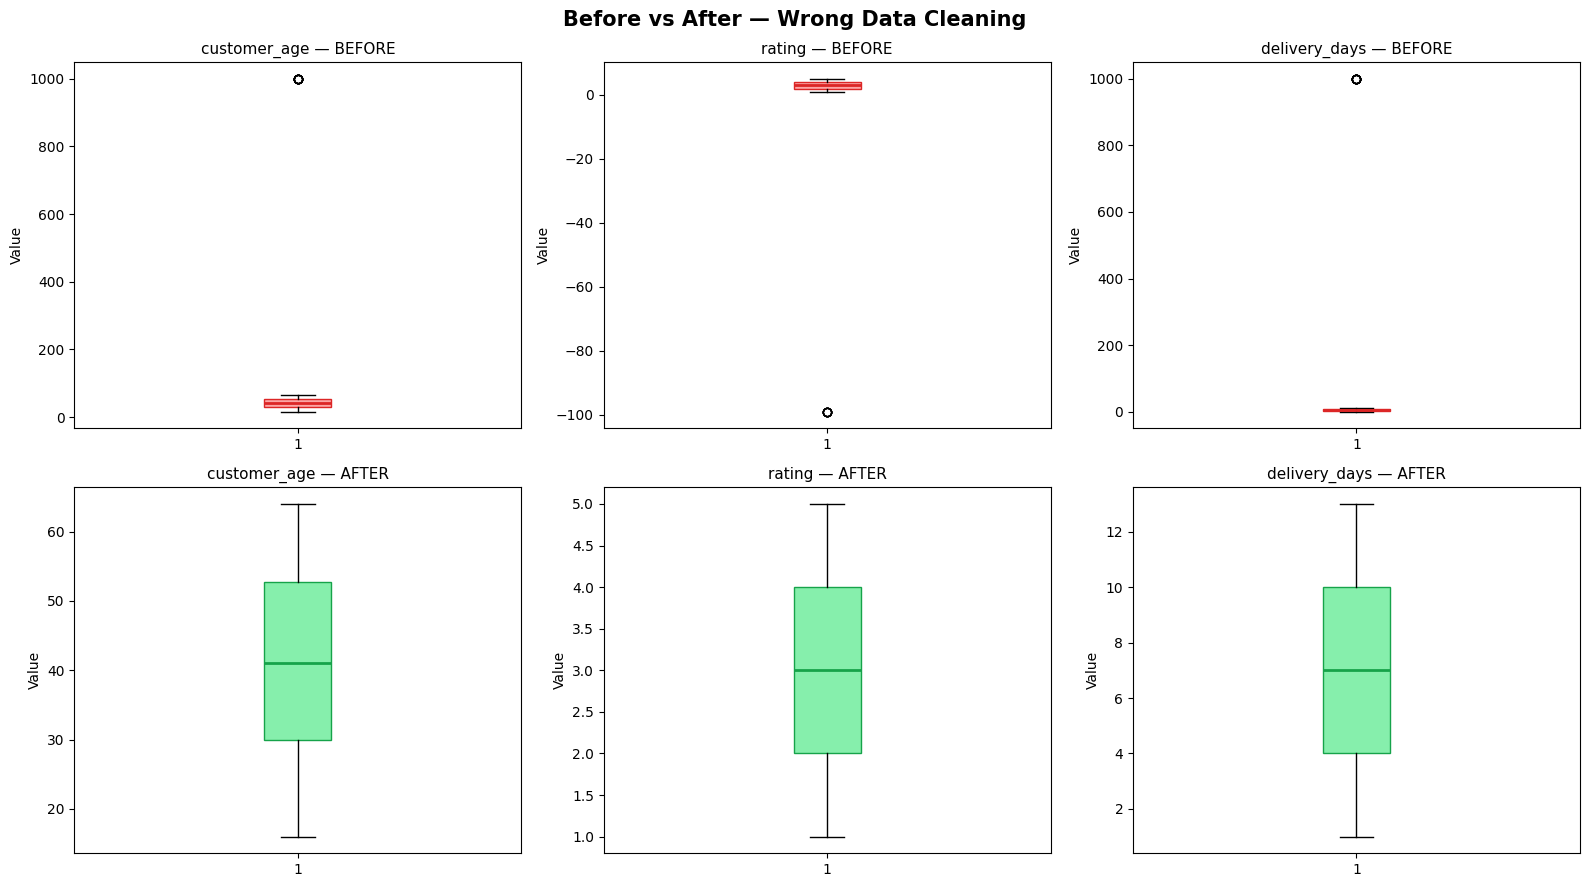

Box plot comparison saved.


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# 2 rows, 3 columns = 6 subplot areas; axes[row, col] accesses each one
fig.suptitle('Before vs After — Wrong Data Cleaning', fontsize=15, fontweight='bold')
# suptitle = 'super title' above all subplots; fontweight='bold' = bold text

cols_compare = ['customer_age', 'rating', 'delivery_days']

for idx, col in enumerate(cols_compare):
    # enumerate gives (index, value) pairs: idx=0 col='customer_age', idx=1 col='rating', etc.

    before_data = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    # raw (dirty) data: convert to numeric, remove NaN for boxplot
    after_data  = df_wd_clean[col].dropna()
    # cleaned data (outliers already replaced)

    # Top row (axes[0, idx]) — BEFORE cleaning — red colour
    axes[0, idx].boxplot(before_data, patch_artist=True,
                         boxprops=dict(facecolor='#fca5a5', color='#dc2626'),
                         # patch_artist=True fills the box; facecolor=light red; color=border red
                         medianprops=dict(color='#dc2626', linewidth=2))
                         # medianprops: median line colour and thickness
    axes[0, idx].set_title(f'{col} — BEFORE', fontsize=11)
    axes[0, idx].set_ylabel('Value')

    # Bottom row (axes[1, idx]) — AFTER cleaning — green colour
    axes[1, idx].boxplot(after_data, patch_artist=True,
                         boxprops=dict(facecolor='#86efac', color='#16a34a'),
                         medianprops=dict(color='#16a34a', linewidth=2))
    axes[1, idx].set_title(f'{col} — AFTER', fontsize=11)
    axes[1, idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('wrong_data_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot comparison saved.")

---
# SECTION 5: Removing Duplicates

---

## Cell 5.1 — Detect Duplicates

---

**`df_dup = df.copy()`**
Fresh raw copy for the duplicates section.

---

**`total_dupes = df_dup.duplicated().sum()`**
`df_dup.duplicated()` returns a boolean Series.
`True` marks the **second and later** occurrences of a duplicated row.
The **first** occurrence is marked `False` (it is the "original").
`.sum()` counts the True values = number of duplicate rows (not counting the first occurrences).

---

**`all_dupe_rows = df_dup[df_dup.duplicated(keep=False)]`**
`keep=False` changes the behaviour: now **ALL copies** of a duplicated row are marked True — including the first occurrence.
This lets you see every row involved in duplication, including the originals.

---

**`print(all_dupe_rows[['order_id','customer_name','product_name','total_amount']].head(10))`**
Shows the duplicates with 4 key columns — you can visually confirm they are identical.

In [31]:
df_dup = df.copy()   # fresh copy of raw data for the duplicates section

# duplicated() returns True for SECOND and later occurrences of duplicate rows
total_dupes = df_dup.duplicated().sum()   # .sum() counts the True values
print(f"Total duplicate rows (2nd+ occurrences): {total_dupes}")
print()

# keep=False marks ALL copies of duplicated rows as True (including the first occurrence)
all_dupe_rows = df_dup[df_dup.duplicated(keep=False)]
# df_dup[condition] filters: keep only rows where condition is True
print(f"All rows involved in duplication (including originals): {len(all_dupe_rows)}")
print()
print("=== Sample duplicate rows ===")
print(all_dupe_rows[['order_id','customer_name','product_name','total_amount']].head(10))

Total duplicate rows (2nd+ occurrences): 30

All rows involved in duplication (including originals): 60

=== Sample duplicate rows ===
       order_id customer_name            product_name  total_amount
53   ORD-100053   Customer_45    Nigerian Law Reports      9,222.72
60   ORD-100060   Customer_45  Golden Penny Rice 25kg     13,140.10
97   ORD-100097   Customer_17    Nigerian Law Reports     19,703.19
132  ORD-100132   Customer_63        Samsung Smart TV    261,528.05
243  ORD-100243   Customer_28      LG Air Conditioner    704,559.04
261  ORD-100261   Customer_75         iPhone 15 128GB    869,324.90
272  ORD-100272   Customer_40      Maybelline Mascara     40,512.48
277  ORD-100277           NaN    Xiaomi Redmi Note 13    921,863.38
278  ORD-100278   Customer_93   Hisense Chest Freezer    879,746.26
306  ORD-100306   Customer_99     WAEC Past Questions     46,884.56


---
## Cell 5.2 — Understanding the `keep=` Parameter

---

**`demo = pd.DataFrame({...})`**
Create a tiny 6-row demonstration DataFrame with 2 duplicate pairs (Chidi appears twice, Amina appears twice).

---

**`demo.duplicated(keep='first').tolist()`**
`keep='first'` = mark only the **second+** occurrences as True. The first occurrence is considered the "original" and is marked False.
Result: `[False, False, False, True, True, False]`
— rows 3 and 4 (the second Chidi and second Amina) are marked True.

**`demo.duplicated(keep='last').tolist()`**
`keep='last'` = mark all occurrences EXCEPT the **last** one as True.
Result: `[True, True, False, False, False, False]`
— rows 0 and 1 (the first Chidi and first Amina) are marked True.

**`demo.duplicated(keep=False).tolist()`**
`keep=False` = mark **ALL** copies (first AND second) as True.
Result: `[True, True, False, True, True, False]`
— all 4 rows involved in duplication are True; Tunde and Ngozi (unique rows) are False.

---

**Why does `keep=` matter?**
When you call `drop_duplicates()`, the `keep=` parameter controls which copy survives:
- `keep='first'` → keep the first record (default — assume first entry is most reliable)
- `keep='last'` → keep the last record (use when the most recent update is most reliable)
- `keep=False` → remove ALL copies (use when you cannot determine which is correct)

In [32]:
# Demonstration: how keep= parameter changes which rows are marked as duplicates
demo = pd.DataFrame({
    'Name'  : ['Chidi', 'Amina', 'Tunde', 'Chidi', 'Amina', 'Ngozi'],
    'Amount': [5000,     12000,   8000,    5000,     12000,   7500  ]
})
print("=== Demo DataFrame ===")
print(demo)
print()

print("duplicated(keep='first') — 2nd+ occurrences marked True (first copy kept):")
print(demo.duplicated(keep='first').tolist())
# [False, False, False, True, True, False]
# rows 3 and 4 (second Chidi, second Amina) are the duplicates

print()
print("duplicated(keep='last')  — all except LAST occurrence marked True:")
print(demo.duplicated(keep='last').tolist())
# [True, True, False, False, False, False]
# rows 0 and 1 (first Chidi, first Amina) are marked True

print()
print("duplicated(keep=False)   — ALL copies of duplicated rows marked True:")
print(demo.duplicated(keep=False).tolist())
# [True, True, False, True, True, False]
# All 4 rows involved in duplication are True; unique rows (Tunde, Ngozi) are False

=== Demo DataFrame ===
    Name  Amount
0  Chidi    5000
1  Amina   12000
2  Tunde    8000
3  Chidi    5000
4  Amina   12000
5  Ngozi    7500

duplicated(keep='first') — 2nd+ occurrences marked True (first copy kept):
[False, False, False, True, True, False]

duplicated(keep='last')  — all except LAST occurrence marked True:
[True, True, False, False, False, False]

duplicated(keep=False)   — ALL copies of duplicated rows marked True:
[True, True, False, True, True, False]


---
## Cell 5.3 — Remove Exact Duplicates

---

**`df_dedup.drop_duplicates(keep='first', inplace=True)`**
`drop_duplicates()` removes duplicate rows from the DataFrame.
`keep='first'` = keep the first occurrence, remove all later copies.
`inplace=True` = modify `df_dedup` directly.

**`df_dedup.reset_index(drop=True, inplace=True)`**
After removing rows, the row index has gaps: `0, 1, 5, 6, 9...`
`reset_index()` renumbers the index from 0 continuously: `0, 1, 2, 3, 4...`
`drop=True` = discard the old index — don't add it as a new column.
`inplace=True` = apply the change directly to `df_dedup`.

**`print(f"Remaining duplicates: {df_dedup.duplicated().sum()} (should be 0)")`**
Always verify after removing duplicates. If this is not 0, the removal did not work completely.

In [33]:
df_dedup = df_dup.copy()   # copy for the actual removal step

print(f"Rows BEFORE removing duplicates : {len(df_dedup)}")

# drop_duplicates() removes duplicate rows
df_dedup.drop_duplicates(keep='first', inplace=True)
# keep='first' = keep first occurrence; remove all 2nd, 3rd... copies
# inplace=True = modify df_dedup directly (no new variable created)

df_dedup.reset_index(drop=True, inplace=True)
# After removing rows, the index has gaps (e.g., 0,1,5,6,9...)
# reset_index() renumbers from 0 continuously: 0,1,2,3,4,...
# drop=True = don't save old index as a column
# inplace=True = apply change directly

print(f"Rows AFTER  removing duplicates : {len(df_dedup)}")
print(f"Rows removed                    : {len(df_dup) - len(df_dedup)}")
print()
print(f"Remaining duplicates: {df_dedup.duplicated().sum()} (should be 0)")
# Final verification — always check this after deduplication

Rows BEFORE removing duplicates : 630
Rows AFTER  removing duplicates : 600
Rows removed                    : 30

Remaining duplicates: 0 (should be 0)


---
## Cell 5.4 — Key-Based Deduplication

---

**`extra = df_keyed.iloc[0:3].copy()`**
`iloc[0:3]` = integer-position slicing: select rows at positions 0, 1, 2 (first 3 rows).
`.copy()` = independent copy so modifying `extra` doesn't change `df_keyed`.

**`extra['total_amount'] = extra['total_amount'] * 1.1`**
Simulate a data conflict: same order ID but slightly different total amount (10% higher).
This is a realistic scenario — the same order was entered twice with different details.

**`df_keyed = pd.concat([df_keyed, extra], ignore_index=True)`**
Stack the original and the conflicting extras together, creating a dataset with duplicate order IDs.

**`df_keyed_dedup = df_keyed.drop_duplicates(subset=['order_id'], keep='last')`**
`subset=['order_id']` = only check for duplicates in the `order_id` column.
`keep='last'` = when the same `order_id` appears twice, keep the LAST one (most recent update wins).
This is the professional approach for "last write wins" data conflicts.

In [34]:
df_keyed = df_dedup.head(20).copy()   # take 20 rows for this demo

# Simulate a data conflict: same order_id appears twice with different total_amount
extra = df_keyed.iloc[0:3].copy()     # copy first 3 rows
# iloc[0:3] = integer position slicing: rows at positions 0, 1, 2 (NOT labels)
extra['total_amount'] = pd.to_numeric(extra['total_amount'], errors='coerce') * 1.1
# Modify total_amount by 10% — simulating an update or re-entry of the same order

df_keyed = pd.concat([df_keyed, extra], ignore_index=True)
# pd.concat() stacks DataFrames vertically (adds rows)
# ignore_index=True resets row index to 0,1,2,3... after stacking

print(f"Rows before key-based dedup  : {len(df_keyed)}")
print(f"Duplicate order_ids           : {df_keyed.duplicated(subset=['order_id']).sum()}")
# subset=['order_id'] = only check duplicates in the order_id column
print()

# Keep the LAST occurrence (most recent/updated record wins)
df_keyed_dedup = df_keyed.drop_duplicates(subset=['order_id'], keep='last')
# subset=['order_id'] = dedup based on order_id only (ignore other column differences)
# keep='last' = keep the last occurrence (most recent update)
df_keyed_dedup.reset_index(drop=True, inplace=True)

print(f"Rows after key-based dedup    : {len(df_keyed_dedup)}")
print(f"Remaining duplicate order_ids  : {df_keyed_dedup.duplicated(subset=['order_id']).sum()}")

Rows before key-based dedup  : 23
Duplicate order_ids           : 3

Rows after key-based dedup    : 20
Remaining duplicate order_ids  : 0


---
## Cell 5.5 — Which Orders Are Duplicated Most?

---

**`order_counts = df_dup['order_id'].value_counts()`**
`value_counts()` counts how many times each unique `order_id` appears.
Returns a Series sorted by frequency: most common first.

**`duplicated_orders = order_counts[order_counts > 1]`**
Filter: keep only order IDs that appear more than once.

**`example_id = duplicated_orders.index[0]`**
`duplicated_orders.index` = the list of duplicate order IDs.
`[0]` = the first one (most duplicated).

**`df_dup[df_dup['order_id'] == example_id]`**
Filter to show ALL rows with this specific order ID — so you can see the exact copies side by side.

In [35]:
# Analyse: which order IDs appear more than once?
order_counts = df_dup['order_id'].value_counts()
# value_counts() counts how many times each unique order_id appears; sorted most-frequent first

duplicated_orders = order_counts[order_counts > 1]
# filter: keep only order_ids that appear MORE than once (actual duplicates)

print(f"Order IDs appearing more than once: {len(duplicated_orders)}")
print()
print("=== Most duplicated orders ===")
print(duplicated_orders.head(10))
print()

# Show all copies of one specific duplicated order side by side
if len(duplicated_orders) > 0:
    example_id = duplicated_orders.index[0]
    # .index gives all the order_id labels; [0] = the most duplicated one
    print(f"=== All copies of order '{example_id}' ===")
    print(df_dup[df_dup['order_id'] == example_id]
          [['order_id','customer_name','product_name','total_amount','rating']])
    # Filter: only rows matching example_id; show 5 key columns

Order IDs appearing more than once: 30

=== Most duplicated orders ===
order_id
ORD-100097    2
ORD-100277    2
ORD-100261    2
ORD-100278    2
ORD-100272    2
ORD-100132    2
ORD-100060    2
ORD-100243    2
ORD-100053    2
ORD-100306    2
Name: count, dtype: int64

=== All copies of order 'ORD-100097' ===
       order_id customer_name          product_name  total_amount  rating
97   ORD-100097   Customer_17  Nigerian Law Reports     19,703.19    3.00
624  ORD-100097   Customer_17  Nigerian Law Reports     19,703.19    3.00


---
## Cell 5.6 — Impact of Duplicates on Analysis

---

This cell is critically important for understanding WHY duplicate removal matters.
It runs the same analysis on both the dirty (with-duplicates) and clean (no-duplicates) datasets and compares the results side by side.

**`df_before = df_dup.copy()`** — the dataset WITH duplicates.
**`df_after = df_dedup.copy()`** — the dataset WITHOUT duplicates.

**`print(f"{'Metric':<30} {'WITH Dupes':>12} {'WITHOUT Dupes':>12}")`**
This is a formatted print creating a table with aligned columns.
`{text:<30}` = left-align in a 30-character field.
`{text:>12}` = right-align in a 12-character field.

**`rev_diff = df_before['total_amount'].sum() - df_after['total_amount'].sum()`**
The revenue overstatement — how much extra (fake) revenue the duplicates were adding.
This number is the financial cost of not removing duplicates.

In [36]:
df_before = df_dup.copy()
df_before['total_amount'] = pd.to_numeric(df_before['total_amount'], errors='coerce')
df_before['rating']       = pd.to_numeric(df_before['rating'],       errors='coerce')

df_after = df_dedup.copy()
df_after['total_amount'] = pd.to_numeric(df_after['total_amount'], errors='coerce')
df_after['rating']       = pd.to_numeric(df_after['rating'],       errors='coerce')

# Side-by-side comparison of key metrics
print("=" * 55)
print(f"{'Metric':<30} {'WITH Dupes':>12} {'WITHOUT':>12}")
# :<30 = left-align in 30 chars; :>12 = right-align in 12 chars (creates a neat table)
print("=" * 55)
print(f"{'Total rows':<30} {len(df_before):>12,} {len(df_after):>12,}")
print(f"{'Total revenue (sum)':<30} {df_before['total_amount'].sum():>12,.0f} {df_after['total_amount'].sum():>12,.0f}")
print(f"{'Avg order value (mean)':<30} {df_before['total_amount'].mean():>12,.0f} {df_after['total_amount'].mean():>12,.0f}")
print(f"{'Avg rating (mean)':<30} {df_before['rating'].mean():>12.3f} {df_after['rating'].mean():>12.3f}")
print(f"{'Unique customers':<30} {df_before['customer_name'].nunique():>12,} {df_after['customer_name'].nunique():>12,}")
# nunique() counts the number of distinct values
print("=" * 55)

rev_diff = df_before['total_amount'].sum() - df_after['total_amount'].sum()
print(f"Revenue OVERSTATEMENT due to duplicates: N{rev_diff:,.0f}")


Metric                           WITH Dupes      WITHOUT
Total rows                              630          600
Total revenue (sum)             181,962,181  172,064,895
Avg order value (mean)              294,914      292,627
Avg rating (mean)                     2.049        1.979
Unique customers                        129          129
Revenue OVERSTATEMENT due to duplicates: N9,897,285


---
## Cell 5.7 — Visual Impact of Duplicates

---

**`fig, axes = plt.subplots(1, 2, figsize=(13, 5))`**
Creates 1 row, 2 columns of subplots (side by side).
`axes[0]` = left chart (before), `axes[1]` = right chart (after).

**`before_cat = df_before.groupby('category')['total_amount'].sum().sort_values(ascending=False)`**
`groupby('category')` = group by product category.
`['total_amount'].sum()` = sum revenue per category.
`.sort_values(ascending=False)` = largest revenue category first.

**`before_cat.plot(kind='bar', ax=axes[0], color='#fca5a5', ...)`**
Light red colour (`#fca5a5`) for the "with duplicates" (danger) chart.

**`after_cat.plot(kind='bar', ax=axes[1], color='#86efac', ...)`**
Light green (`#86efac`) for the "without duplicates" (correct) chart.

The visual comparison makes it immediately obvious that every bar is slightly shorter after removing duplicates — showing the inflated revenue caused by duplicates.

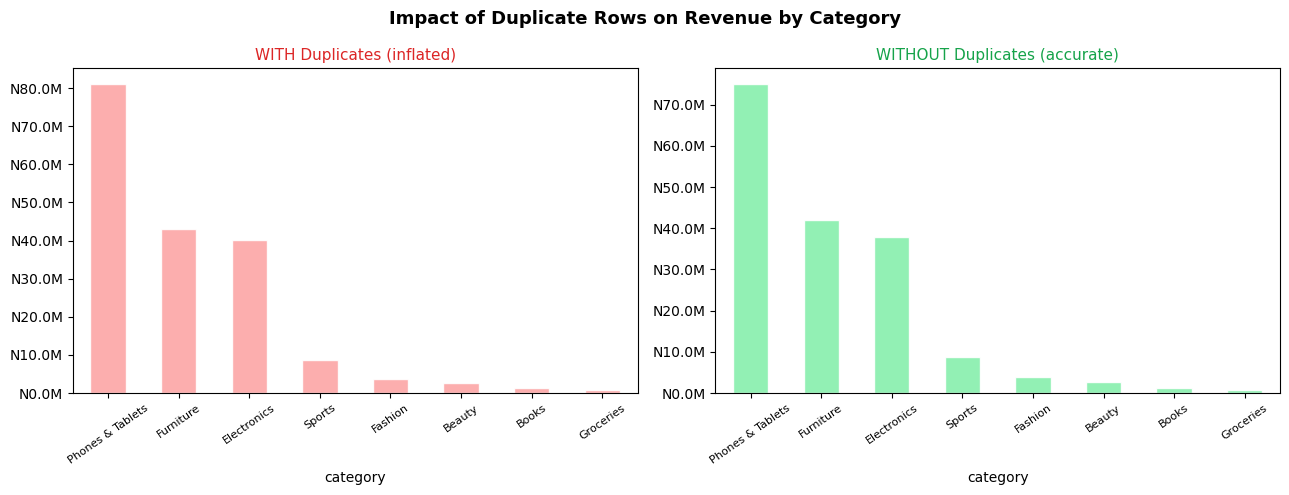

Chart saved. Notice every bar is slightly shorter without duplicates.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# 1 row, 2 columns of subplots; axes[0]=left, axes[1]=right
fig.suptitle('Impact of Duplicate Rows on Revenue by Category', fontsize=13, fontweight='bold')

# Left chart — WITH duplicates (inflated)
before_cat = df_before.groupby('category')['total_amount'].sum().sort_values(ascending=False)
# groupby('category') groups rows by category; .sum() totals revenue per group
before_cat.plot(kind='bar', ax=axes[0], color='#fca5a5', edgecolor='white', alpha=0.9)
# color='#fca5a5' = light red (danger colour for the inflated chart)
axes[0].set_title('WITH Duplicates (inflated)', fontsize=11, color='#dc2626')
axes[0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))
# Format y-axis: 5000000 → 'N5.0M' using a lambda FuncFormatter

# Right chart — WITHOUT duplicates (accurate)
after_cat = df_after.groupby('category')['total_amount'].sum().sort_values(ascending=False)
after_cat.plot(kind='bar', ax=axes[1], color='#86efac', edgecolor='white', alpha=0.9)
# color='#86efac' = light green (correct/clean chart)
axes[1].set_title('WITHOUT Duplicates (accurate)', fontsize=11, color='#16a34a')
axes[1].tick_params(axis='x', rotation=35, labelsize=8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('duplicates_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved. Notice every bar is slightly shorter without duplicates.")

---
# SECTION 6: The Complete Cleaning Pipeline

---

## Cells 6.1–6.9 — All 9 Steps

These cells run the complete professional pipeline from raw to clean in sequence.
Every step is explained inside the cell as inline comments.
Run them top to bottom — each step depends on the previous one.

In [38]:
# ═══ STEP 1: LOAD ═══
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('nigeria_cleaning_dataset.csv')
# Always load into a named variable — never overwrite the file
print(f"[STEP 1] Loaded: {df.shape[0]} rows x {df.shape[1]} columns")

[STEP 1] Loaded: 630 rows x 20 columns


In [39]:
# ═══ STEP 2: REMOVE DUPLICATES (do this FIRST — no need to clean rows you'll delete) ═══
dupes_before = df.duplicated().sum()
# duplicated().sum() = count duplicate rows before removal
df.drop_duplicates(keep='first', inplace=True)  # keep first occurrence, remove rest
df.reset_index(drop=True, inplace=True)         # renumber index after gaps from removal
print(f"[STEP 2] Removed {dupes_before} duplicates | Rows now: {len(df)}")

[STEP 2] Removed 30 duplicates | Rows now: 600


In [40]:
# ═══ STEP 3: CONVERT DATA TYPES ═══
# Numeric columns — convert all to float; non-numeric → NaN
for col in ['unit_price','quantity','discount_pct','total_amount','customer_age','rating','delivery_days']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # errors='coerce': invalid strings (like '999abc') → NaN instead of crashing

# Date column — replace 'N/A' string first, then parse
df['order_date'] = df['order_date'].replace('N/A', np.nan)
# replace() swaps the string 'N/A' with the actual NaN marker
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
# pd.to_datetime(): parse dates; dayfirst=True for DD/MM/YYYY; errors='coerce' → NaT

print(f"[STEP 3] Types fixed | order_date dtype: {df['order_date'].dtype}")

[STEP 3] Types fixed | order_date dtype: datetime64[ns]


In [41]:
# ═══ STEP 4: REPLACE IMPOSSIBLE / WRONG VALUES WITH NaN ═══
# .loc[condition, column] = np.nan : set cells matching condition to missing

df.loc[df['customer_age'] > 100,  'customer_age']  = np.nan  # no one is > 100 years old
df.loc[df['customer_age'] < 1,    'customer_age']  = np.nan  # no negative ages
df.loc[df['rating'] < 1,          'rating']        = np.nan  # rating below 1 impossible
df.loc[df['rating'] > 5,          'rating']        = np.nan  # rating above 5 impossible
df.loc[df['delivery_days'] > 30,  'delivery_days'] = np.nan  # > 30 days unrealistic
df.loc[df['delivery_days'] < 1,   'delivery_days'] = np.nan  # negative delivery impossible
df.loc[df['total_amount'] <= 0,   'total_amount']  = np.nan  # order must have positive value
df.loc[df['unit_price'] <= 0,     'unit_price']    = np.nan  # price must be positive

# Invalid state values → NaN
VALID_STATES = ['Lagos','Abuja','Kano','Rivers','Oyo','Delta','Kaduna','Enugu','Anambra','Imo']
df.loc[~df['state'].isin(VALID_STATES) & df['state'].notna(), 'state'] = np.nan
# ~.isin() = NOT in the valid list; & .notna() = AND not already NaN

print(f"[STEP 4] Wrong values replaced | NaN count now: {df.isnull().sum().sum()}")

[STEP 4] Wrong values replaced | NaN count now: 607


In [42]:
# ═══ STEP 5: FILL EMPTY CELLS ═══
# Numeric: fill with median (safe for skewed data with outliers)
df['customer_age'].fillna(df['customer_age'].median(),   inplace=True)
df['rating'].fillna(df['rating'].median(),               inplace=True)
df['delivery_days'].fillna(df['delivery_days'].median(), inplace=True)
df['total_amount'].fillna(df['total_amount'].median(),   inplace=True)
df['unit_price'].fillna(df['unit_price'].median(),       inplace=True)

# Date: fill with mode (most common date)
df['order_date'].fillna(df['order_date'].mode()[0],      inplace=True)
# mode()[0] = most frequent value; [0] because mode() returns a Series

# Categorical: fill with mode (most common category)
df['state'].fillna(df['state'].mode()[0],                    inplace=True)
df['customer_segment'].fillna(df['customer_segment'].mode()[0], inplace=True)
df['payment_method'].fillna(df['payment_method'].mode()[0],  inplace=True)

# Text: fill with meaningful placeholders
df['customer_name'].fillna('Unknown Customer',               inplace=True)
df['customer_email'].fillna('no-email@placeholder.ng',       inplace=True)
df['customer_phone'] = df['customer_phone'].astype(object)   # convert to object dtype first
df['customer_phone'].fillna('0000000000',                    inplace=True)

print(f"[STEP 5] Cells filled | NaN remaining: {df.isnull().sum().sum()} (target: 0)")

[STEP 5] Cells filled | NaN remaining: 0 (target: 0)


In [43]:
# ═══ STEP 6: STANDARDISE STRINGS ═══
# .str.strip() removes leading/trailing whitespace
# .str.title() capitalises First Letter Of Each Word
for col in ['customer_name','state','category','product_name','payment_method',
            'customer_segment','platform','customer_gender']:
    df[col] = df[col].str.strip().str.title()
    # Chain: strip first (remove spaces), then title-case
    # Fixes: 'LAGOS' → 'Lagos', '  lagos  ' → 'Lagos', 'lagos' → 'Lagos'

# Phone cleaning function
def clean_phone(p):
    if pd.isna(p): return 'UNKNOWN'
    p = str(p).strip()
    p = re.sub(r'[\s\-\(\)]', '', p)     # remove spaces, hyphens, brackets
    if p.startswith('+234'): p = '0' + p[4:]  # international → local format
    if len(p)==10 and p[0] in '789': p = '0' + p  # prepend missing 0
    return p if re.match(r'^0[7-9][0-1]\d{8}$', p) else 'INVALID'
    # Final validation: must be 11 digits in Nigerian format

df['customer_phone_clean'] = df['customer_phone'].apply(clean_phone)
# apply() runs clean_phone on every value in the column
print(f"[STEP 6] Strings standardised | Invalid phones: {(df['customer_phone_clean']=='INVALID').sum()}")

[STEP 6] Strings standardised | Invalid phones: 600


In [44]:
# ═══ STEP 7: ADD DERIVED COLUMNS (Feature Engineering) ═══
df['total_recalc']    = df['unit_price'] * df['quantity'] * (1 - df['discount_pct']/100)
# Recalculate total from components — more reliable after cleaning
# unit_price x quantity = gross; x (1 - discount%) = net after discount

df['order_year']      = df['order_date'].dt.year         # extract year from datetime
df['order_month']     = df['order_date'].dt.month        # extract month number
df['order_monthname'] = df['order_date'].dt.month_name() # full month name string
df['order_quarter']   = 'Q' + df['order_date'].dt.quarter.astype(str)
# dt.quarter returns 1,2,3,4; astype(str) converts to string; + 'Q' prefix → 'Q1','Q2'...

df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0,17,25,35,45,55,65,110],
    labels=['Under 18','18-25','26-35','36-45','46-55','56-65','65+'],
    right=True
)
# pd.cut() bins a continuous variable into labelled categories

df['is_high_value'] = df['total_amount'] > df['total_amount'].median()
# Boolean flag: True if this order's total is above the median order value

df['discount_tier'] = pd.cut(
    df['discount_pct'], bins=[-1,0,9,14,19,100],
    labels=['No Discount','0-9%','10-14%','15-19%','20%+'], right=True
)

print("[STEP 7] Derived columns added")
print(df[['order_date','order_quarter','age_group','discount_tier','is_high_value']].head(5))

[STEP 7] Derived columns added
  order_date order_quarter age_group discount_tier  is_high_value
0 2023-01-01            Q1     56-65        15-19%           True
1 2023-02-01            Q1     36-45          0-9%          False
2 2023-01-01            Q1     46-55   No Discount           True
3 2023-04-01            Q2     18-25        10-14%           True
4 2023-05-01            Q2     56-65          0-9%          False


In [45]:
# ═══ STEP 8: VALIDATE — CONFIRM CLEAN ═══
print("=" * 60)
print("FINAL VALIDATION REPORT")
print("=" * 60)
print(f"  Final shape      : {df.shape}")
print(f"  Duplicate rows   : {df.duplicated().sum()} (target: 0)")
print(f"  Missing values   : {df.isnull().sum().sum()} (target: 0)")
print()

# Range checks using .between(min, max) — returns True if value is in range
checks = [
    ('customer_age',   df['customer_age'].between(1, 100).all(),  "1–100"),
    ('rating',         df['rating'].between(1, 5).all(),          "1–5"),
    ('delivery_days',  df['delivery_days'].between(1, 30).all(),  "1–30"),
    ('total_amount',   (df['total_amount'] > 0).all(),            "> 0"),
]
# .all() returns True only if EVERY value in the boolean Series is True
# If any value is out of range, .all() = False → FAIL

print("  Range validation:")
for col, passed, expected in checks:
    print(f"    {col:<20} {'PASS' if passed else 'FAIL'}  (expected: {expected})")
print("=" * 60)

FINAL VALIDATION REPORT
  Final shape      : (600, 29)
  Duplicate rows   : 0 (target: 0)
  Missing values   : 0 (target: 0)

  Range validation:
    customer_age         PASS  (expected: 1–100)
    rating               PASS  (expected: 1–5)
    delivery_days        PASS  (expected: 1–30)
    total_amount         PASS  (expected: > 0)


In [46]:
# ═══ STEP 9: EXPORT CLEAN DATA ═══
df.to_csv('nigeria_ecommerce_CLEAN.csv', index=False)
# to_csv() saves the DataFrame as a CSV file
# index=False: do NOT write the row index (0,1,2...) as a column in the file

df.to_excel('nigeria_ecommerce_CLEAN.xlsx', index=False, sheet_name='Clean_Data', engine='openpyxl')
# to_excel() saves as Excel; sheet_name sets the worksheet name; openpyxl is the writer engine

import os
csv_size  = os.path.getsize('nigeria_ecommerce_CLEAN.csv')  / 1024
xlsx_size = os.path.getsize('nigeria_ecommerce_CLEAN.xlsx') / 1024
# os.path.getsize() returns file size in bytes; /1024 converts to kilobytes

print(f"[STEP 9] CSV saved  : nigeria_ecommerce_CLEAN.csv  ({csv_size:.1f} KB)")
print(f"[STEP 9] Excel saved: nigeria_ecommerce_CLEAN.xlsx ({xlsx_size:.1f} KB)")

[STEP 9] CSV saved  : nigeria_ecommerce_CLEAN.csv  (139.3 KB)
[STEP 9] Excel saved: nigeria_ecommerce_CLEAN.xlsx (97.4 KB)


---
# SECTION 7: Post-Cleaning Analysis

---

## Cell 7.1 — Revenue Analysis on Clean Data

---

**`cat_rev = df.groupby('category').agg(Orders=('order_id','count'), Revenue=('total_amount','sum'), Avg_Order=('total_amount','mean'), Avg_Rating=('rating','mean')).round(2).sort_values('Revenue', ascending=False)`**

**`df.groupby('category')`** — splits the DataFrame into groups, one per unique category value.

**`.agg(Orders=('order_id','count'), ...)`** — named aggregation syntax. Format: `new_column_name = ('source_column', 'function')`.
- `Orders = ('order_id', 'count')` → count rows per category
- `Revenue = ('total_amount', 'sum')` → total revenue per category
- `Avg_Order = ('total_amount', 'mean')` → average order value per category
- `Avg_Rating = ('rating', 'mean')` → average customer rating per category

**`.round(2)`** — round all values to 2 decimal places.

**`.sort_values('Revenue', ascending=False)`** — sort by Revenue column, largest first.

**`print(cat_rev.to_string())`** — `.to_string()` prevents Pandas from truncating rows/columns. Forces the full table to print.

In [47]:
print("=== Revenue by Category — Clean Data ===")
cat_rev = df.groupby('category').agg(
    Orders     = ('order_id',     'count'),  # count rows per category = number of orders
    Revenue    = ('total_amount', 'sum'  ),  # sum of total_amount per category
    Avg_Order  = ('total_amount', 'mean' ),  # average order value per category
    Avg_Rating = ('rating',       'mean' )   # average customer rating per category
).round(2).sort_values('Revenue', ascending=False)
# .round(2) = round all values to 2 decimal places
# .sort_values('Revenue', ascending=False) = sort by Revenue, largest first

print(cat_rev.to_string())  # .to_string() forces full output — no truncation of rows or columns

=== Revenue by Category — Clean Data ===
                  Orders       Revenue    Avg_Order  Avg_Rating
category                                                       
Phones & Tablets      75 75,255,877.51 1,003,411.70        3.12
Furniture             60 41,947,203.55   699,120.06        3.07
Electronics           82 38,166,454.90   465,444.57        3.15
Sports                74  8,996,965.80   121,580.62        3.08
Fashion               64  3,979,578.61    62,180.92        2.92
Beauty                86  2,782,881.89    32,359.09        2.87
Books                 87  1,633,298.84    18,773.55        3.24
Groceries             72    922,138.86    12,807.48        2.99


---
## Cell 7.2 — Post-Cleaning Dashboard (4 Charts)

---

**`fig, axes = plt.subplots(2, 2, figsize=(16, 11))`**
2 rows × 2 columns = 4 subplots. `axes[0,0]`=top-left, `axes[0,1]`=top-right, `axes[1,0]`=bottom-left, `axes[1,1]`=bottom-right.

**`fig.suptitle('Nigeria E-Commerce — Post-Cleaning Analysis Dashboard', fontsize=15, fontweight='bold')`**
Title above all 4 charts.

**Chart 1 — Revenue by Category (horizontal bar)**
`df.groupby('category')['total_amount'].sum()` — group and sum.
`.sort_values(ascending=True)` — smallest at bottom when using `barh` (horizontal bar).
`kind='barh'` — horizontal bar chart; better when category names are long.
`xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.0f}M'))` — format x-axis ticks in millions.

**Chart 2 — Orders by State (bar)**
`df['state'].value_counts().head(10)` — top 10 states by order count.

**Chart 3 — Age Distribution (histogram)**
`df['customer_age'].plot(kind='hist', bins=20, ...)` — histogram with 20 equal-width bins.

**Chart 4 — Rating Distribution (bar)**
`df['rating'].value_counts().sort_index()` — count each rating (1,2,3,4,5); sort by rating value.
`.plot(kind='bar', ...)` — vertical bar chart.

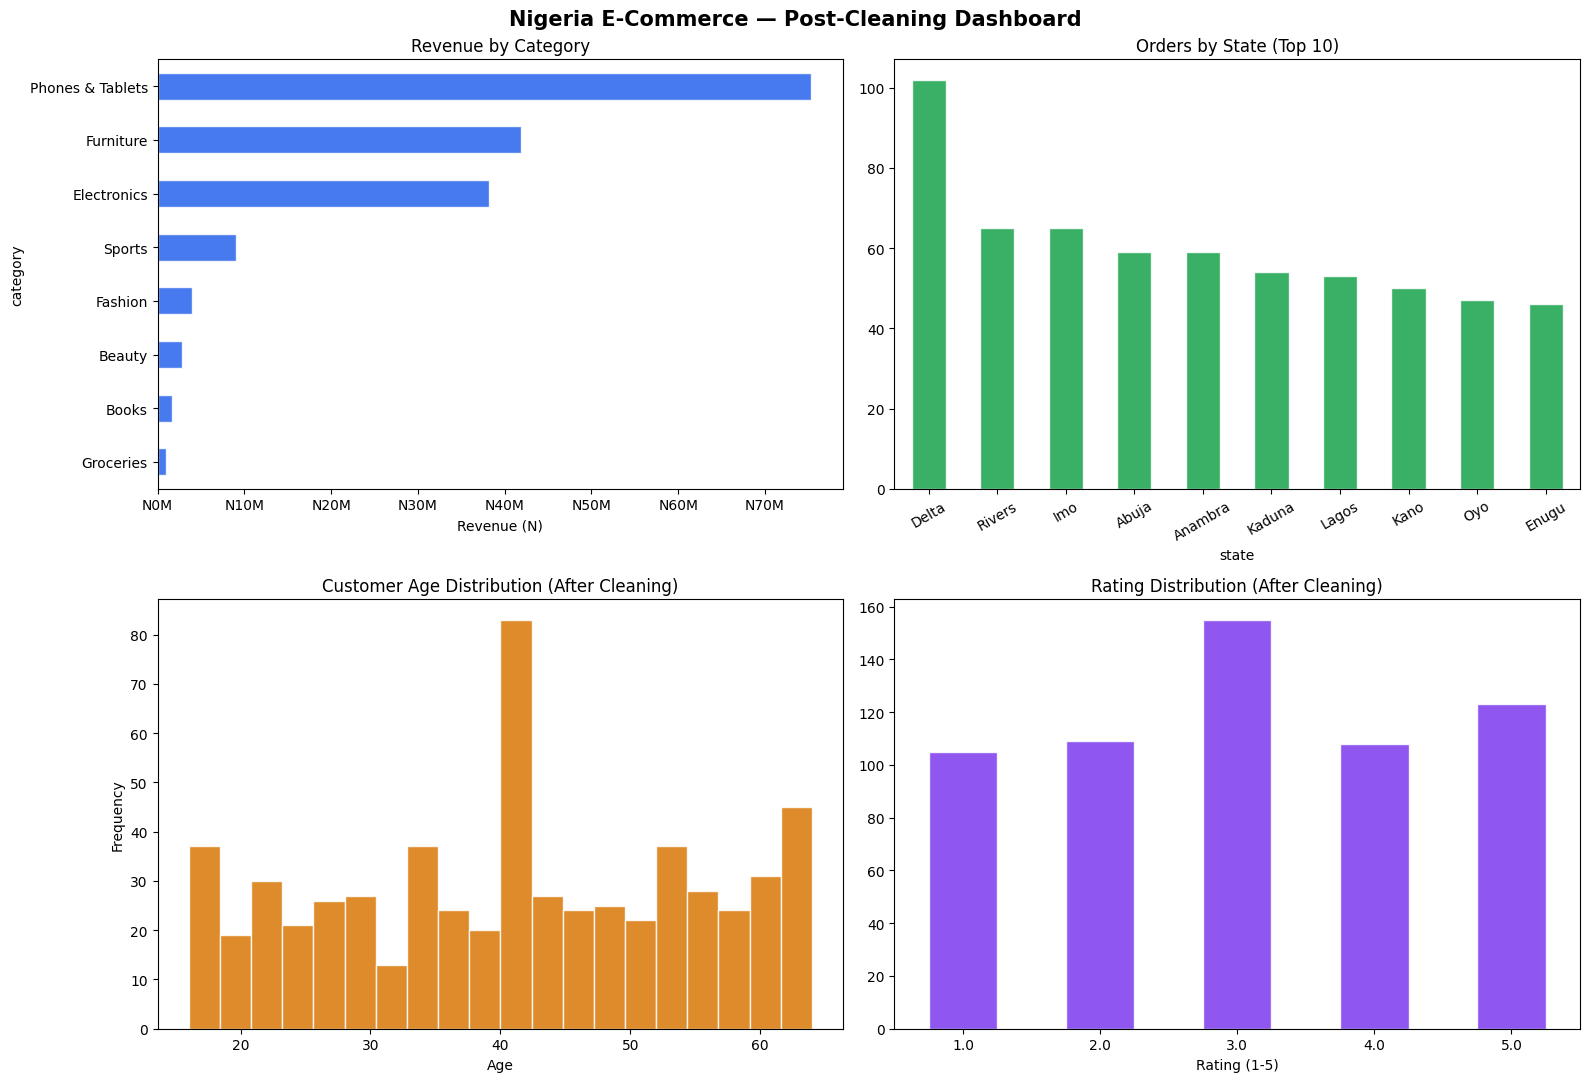

Dashboard saved.


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# 2 rows x 2 cols = 4 subplots; access each with axes[row, col]
fig.suptitle('Nigeria E-Commerce — Post-Cleaning Dashboard', fontsize=15, fontweight='bold')

# Chart 1 (top-left): Revenue by Category — horizontal bar
cat_rev_plot = df.groupby('category')['total_amount'].sum().sort_values(ascending=True)
# groupby + sum = total revenue per category; ascending=True = smallest bar at bottom for barh
cat_rev_plot.plot(kind='barh', ax=axes[0,0], color='#2563eb', alpha=0.85, edgecolor='white')
# kind='barh' = horizontal bar chart; good for long category names
axes[0,0].set_title('Revenue by Category')
axes[0,0].set_xlabel('Revenue (N)')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.0f}M'))
# FuncFormatter: custom x-axis label function; 5000000 → 'N5M'

# Chart 2 (top-right): Orders by State — vertical bar
state_cnt = df['state'].value_counts().head(10)
# value_counts() = frequency of each state; head(10) = top 10 states only
state_cnt.plot(kind='bar', ax=axes[0,1], color='#16a34a', alpha=0.85, edgecolor='white')
axes[0,1].set_title('Orders by State (Top 10)')
axes[0,1].tick_params(axis='x', rotation=30)  # tilt labels 30 degrees

# Chart 3 (bottom-left): Customer Age Distribution — histogram
df['customer_age'].plot(kind='hist', bins=20, ax=axes[1,0], color='#d97706', alpha=0.85, edgecolor='white')
# bins=20 = divide range into 20 equal-width buckets
axes[1,0].set_title('Customer Age Distribution (After Cleaning)')
axes[1,0].set_xlabel('Age')

# Chart 4 (bottom-right): Rating Distribution — bar chart
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='#7c3aed', alpha=0.85, edgecolor='white')
# sort_index() sorts by rating value (1,2,3,4,5) not by frequency
axes[1,1].set_title('Rating Distribution (After Cleaning)')
axes[1,1].set_xlabel('Rating (1-5)')
axes[1,1].tick_params(axis='x', rotation=0)   # keep x labels upright

plt.tight_layout()   # auto-adjust spacing between subplots
plt.savefig('post_cleaning_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

---
# SECTION 8: Applying Cleaning to Excel Sheets

---

## Cell 8.1 — EmptyCells_Demo Sheet

---

**`df_empty = pd.read_excel('nigeria_cleaning_dataset.xlsx', sheet_name='EmptyCells_Demo', na_values=[...])`**
`pd.read_excel()` reads an Excel file. `sheet_name='EmptyCells_Demo'` loads that specific sheet.
`na_values=['N/A','missing','--','none','Unknown']` = treat these strings as NaN at load time.

**`for col in ['customer_age','rating','total_amount','delivery_days']: df_empty[col] = pd.to_numeric(df_empty[col], errors='coerce')`**
A loop that converts multiple columns to numeric in one compact block. `errors='coerce'` ensures non-numeric values become NaN rather than crashing.

**`df_empty.loc[df_empty['customer_age'] > 100, 'customer_age'] = np.nan`**
Replace impossible ages (> 100) with NaN using the standard `.loc[condition, column] = value` pattern.

**`for col in ['customer_age','rating','total_amount','delivery_days']: df_empty[col].fillna(df_empty[col].median(), inplace=True)`**
Fill the NaN values for each of these 4 columns with their respective medians in one loop.
`df_empty[col].median()` computes the median of the CURRENT column (after outliers were replaced with NaN).

In [49]:
# Load the EmptyCells_Demo sheet from the Excel file
df_empty = pd.read_excel(
    'nigeria_cleaning_dataset.xlsx',
    sheet_name='EmptyCells_Demo',          # load this specific sheet
    na_values=['N/A','missing','--','none','Unknown']  # these strings → NaN at load time
)

print("=== EmptyCells_Demo — before cleaning ===")
print(f"Shape: {df_empty.shape}")
print(df_empty.isnull().sum()[df_empty.isnull().sum() > 0])
# double filter: isnull().sum() gives counts; [counts > 0] shows only columns with missing
print()

# Convert numeric columns and replace outliers with NaN
for col in ['customer_age','rating','total_amount','delivery_days']:
    df_empty[col] = pd.to_numeric(df_empty[col], errors='coerce')
    # loop applies same conversion to all 4 columns; non-numeric → NaN

df_empty.loc[df_empty['customer_age'] > 100, 'customer_age']  = np.nan  # impossible age
df_empty.loc[df_empty['rating'] < 1,          'rating']        = np.nan  # impossible rating
df_empty.loc[df_empty['rating'] > 5,          'rating']        = np.nan
df_empty.loc[df_empty['total_amount'] <= 0,   'total_amount']  = np.nan  # impossible amount
df_empty.loc[df_empty['delivery_days'] > 30,  'delivery_days'] = np.nan  # impossible delivery

# Fill NaN with median (loop over the same 4 columns)
for col in ['customer_age','rating','total_amount','delivery_days']:
    df_empty[col].fillna(df_empty[col].median(), inplace=True)
    # df_empty[col].median() = median of remaining valid values for this column

df_empty['customer_name'].fillna('Unknown Customer',           inplace=True)
df_empty['customer_email'].fillna('no-email@placeholder.ng',  inplace=True)
df_empty['customer_phone'] = df_empty['customer_phone'].astype(object)
df_empty['customer_phone'].fillna('0000000000',               inplace=True)
df_empty['state'].fillna(df_empty['state'].mode()[0],         inplace=True)

print("=== After cleaning ===")
print(f"Missing values remaining: {df_empty.isnull().sum().sum()}")

=== EmptyCells_Demo — before cleaning ===
Shape: (200, 9)
customer_name     13
customer_email     8
customer_phone     6
state              4
customer_age      12
rating             9
total_amount       5
delivery_days      2
dtype: int64

=== After cleaning ===
Missing values remaining: 0


---
## Cell 8.2 — Duplicates_Demo Sheet

---

**`df_dup_xl = pd.read_excel('nigeria_cleaning_dataset.xlsx', sheet_name='Duplicates_Demo')`**
Load the Duplicates_Demo sheet. No `na_values` needed here — we are focused only on duplicates.

**`print(f"Rows: {len(df_dup_xl)}  |  Duplicates: {df_dup_xl.duplicated().sum()}")`**
Before/after comparison — shows how many duplicates existed before removal.

**`df_dup_xl.drop_duplicates(keep='first', inplace=True)`**
Remove duplicate rows, keeping the first occurrence of each.

**`df_dup_xl.reset_index(drop=True, inplace=True)`**
After removing rows, renumber the row index cleanly from 0.

**`print(f"Rows: {len(df_dup_xl)}  |  Duplicates: {df_dup_xl.duplicated().sum()}")`**
Verification after removal — duplicates should now be 0.

In [50]:
# Load the Duplicates_Demo sheet
df_dup_xl = pd.read_excel(
    'nigeria_cleaning_dataset.xlsx',
    sheet_name='Duplicates_Demo'   # load only this sheet
)

print("=== Duplicates_Demo — before ===")
print(f"Rows: {len(df_dup_xl)}  |  Duplicates: {df_dup_xl.duplicated().sum()}")
# len() = row count; duplicated().sum() = count of duplicate rows (2nd+ occurrences)
print()

df_dup_xl.drop_duplicates(keep='first', inplace=True)
# drop_duplicates(): remove duplicate rows; keep='first' = keep first copy; inplace=True = modify directly

df_dup_xl.reset_index(drop=True, inplace=True)
# reset_index(): renumber row index 0,1,2,3... after gaps left by removed rows
# drop=True = discard old index; inplace=True = apply directly

print("=== After removing duplicates ===")
print(f"Rows: {len(df_dup_xl)}  |  Duplicates: {df_dup_xl.duplicated().sum()}")
# duplicates should now be 0

=== Duplicates_Demo — before ===
Rows: 175  |  Duplicates: 25

=== After removing duplicates ===
Rows: 150  |  Duplicates: 0


---
## Cell 8.3 — WrongFormat_Demo Sheet

---

**`df_fmt_xl = pd.read_excel('nigeria_cleaning_dataset.xlsx', sheet_name='WrongFormat_Demo', na_values=['N/A','missing','--'])`**
Load the WrongFormat_Demo sheet, converting common missing-value strings to NaN.

**`print(df_fmt_xl.dtypes)`**
Show data types BEFORE fixing. You should see `order_date` as `object` (text) rather than `datetime64`.

**`df_fmt_xl['order_date'] = df_fmt_xl['order_date'].replace('N/A', np.nan)`**
Replace the literal string `'N/A'` with actual NaN before parsing dates.

**`df_fmt_xl['order_date'] = pd.to_datetime(df_fmt_xl['order_date'], dayfirst=True, errors='coerce')`**
Convert all date formats to uniform `datetime64`. `dayfirst=True` handles DD/MM/YYYY format. `errors='coerce'` handles any remaining unparseable dates.

**`for col in ['customer_age','rating','delivery_days']: df_fmt_xl[col] = pd.to_numeric(df_fmt_xl[col], errors='coerce')`**
Convert numeric columns in a loop.

**`print(df_fmt_xl['order_date'].head(6))`**
Confirm the dates now display as proper datetime objects: `2024-01-05`, `2024-01-06`, etc.

In [51]:
# Load the WrongFormat_Demo sheet
df_fmt_xl = pd.read_excel(
    'nigeria_cleaning_dataset.xlsx',
    sheet_name='WrongFormat_Demo',
    na_values=['N/A','missing','--']   # these strings → NaN at load time
)

print("=== WrongFormat_Demo — dtypes BEFORE fixing ===")
print(df_fmt_xl.dtypes)
# Look at order_date — it will show 'object' (text) before conversion
print()

# Fix order_date: replace 'N/A' string first, then convert to datetime
df_fmt_xl['order_date'] = df_fmt_xl['order_date'].replace('N/A', np.nan)
# replace() swaps the text 'N/A' with actual NaN — must do before pd.to_datetime()
df_fmt_xl['order_date'] = pd.to_datetime(df_fmt_xl['order_date'], dayfirst=True, errors='coerce')
# pd.to_datetime(): parse mixed date formats; dayfirst=True for DD/MM/YYYY; errors='coerce' → NaT

# Fix numeric columns using a loop
for col in ['customer_age','rating','delivery_days']:
    df_fmt_xl[col] = pd.to_numeric(df_fmt_xl[col], errors='coerce')
    # same operation on all 3 columns; errors='coerce' turns non-numeric into NaN

print("=== Dtypes AFTER fixing ===")
print(df_fmt_xl.dtypes)
# order_date should now show datetime64[ns]
print()
print("=== Sample order_dates after fix ===")
print(df_fmt_xl['order_date'].head(6))
# Should display as 2024-01-05, 2024-01-06... (uniform datetime format)

=== WrongFormat_Demo — dtypes BEFORE fixing ===
order_id           object
order_date         object
customer_name      object
customer_phone    float64
customer_email     object
customer_age      float64
rating            float64
delivery_days     float64
dtype: object

=== Dtypes AFTER fixing ===
order_id                  object
order_date        datetime64[ns]
customer_name             object
customer_phone           float64
customer_email            object
customer_age             float64
rating                   float64
delivery_days            float64
dtype: object

=== Sample order_dates after fix ===
0   2023-01-01
1   2023-02-01
2          NaT
3   2023-04-01
4   2023-05-01
5   2023-07-01
Name: order_date, dtype: datetime64[ns]


---
# Complete Data Cleaning Cheat Sheet

---

## Detecting Problems
```python
df.info()                              # column types + non-null count
df.isnull().sum()                      # missing count per column
df.isnull().sum().sum()                # total missing cells in whole DataFrame
df.duplicated().sum()                  # count duplicate rows
df.describe()                          # stats — look at min/max for impossible values
df['col'].value_counts(dropna=False)   # frequency table, including NaN
df[df['col'].isnull()]                 # show only rows where col is NaN
df[df.isnull().any(axis=1)]            # show rows with ANY missing value
```

---

## Cleaning Empty Cells
```python
df.dropna()                            # remove rows with any NaN
df.dropna(subset=['col'])              # remove rows only where 'col' is NaN
df.dropna(how='all')                   # remove only fully-empty rows
df.dropna(thresh=n)                    # keep rows with at least n non-null values

df['col'].fillna(value, inplace=True)           # fill with constant
df['col'].fillna(df['col'].mean(), inplace=True)  # fill with mean
df['col'].fillna(df['col'].median(), inplace=True) # fill with median
df['col'].fillna(df['col'].mode()[0], inplace=True) # fill with mode
df['col'].ffill(inplace=True)          # forward fill
df['col'].bfill(inplace=True)          # backward fill
```

---

## Cleaning Wrong Format
```python
pd.to_datetime(df['col'], dayfirst=True, errors='coerce')  # fix dates
pd.to_numeric(df['col'], errors='coerce')                  # fix numbers

df['col'].dt.year / .month / .month_name() / .day_name() / .quarter  # date parts

df['col'].str.strip()                  # remove whitespace
df['col'].str.title()                  # First Letter Capitalised
df['col'].str.lower()                  # all lowercase
df['col'].str.upper()                  # ALL UPPERCASE
df['col'].str.replace('old','new')     # replace substring
re.match(pattern, value)               # check if value matches pattern
re.sub(pattern, '', value)             # remove all matching characters
```

---

## Cleaning Wrong Data
```python
df.loc[df['col'] > max_val, 'col'] = np.nan    # replace impossible high values
df.loc[df['col'] < min_val, 'col'] = np.nan    # replace impossible low values
df['col'].replace({'bad_val': np.nan})          # replace specific wrong values

np.where(condition, value_if_true, value_if_false)  # conditional (like Excel IF)
pd.cut(df['col'], bins=[...], labels=[...])         # bin into categories
```

---

## Removing Duplicates
```python
df.duplicated().sum()                          # count duplicates
df[df.duplicated(keep=False)]                  # view ALL copies of duplicated rows
df.drop_duplicates(keep='first', inplace=True) # remove; keep first occurrence
df.drop_duplicates(subset=['id_col'])          # dedup based on key column only
df.reset_index(drop=True, inplace=True)        # renumber index after removal
```

---

## Professional Cleaning Order
```
1. Load raw data                (pd.read_csv / pd.read_excel)
2. Audit                        (info, isnull, describe, duplicated)
3. Remove duplicates            (drop_duplicates → reset_index)
4. Fix data types               (to_numeric, to_datetime)
5. Fix wrong data               (loc conditions → np.nan)
6. Fill empty cells             (fillna with median/mode/constant)
7. Fix string formats           (str.strip, str.title, re.sub)
8. Add derived columns          (feature engineering)
9. Validate                     (isnull().sum(), duplicated().sum(), describe())
10. Export                      (to_csv, to_excel)
```

---

> *"Clean data is not perfect data — it is data that is fit for its purpose."*
> — **Prodigy Training Hub**